# Bibliotekos

In [21]:
import pandas as pd
import numpy as np
import torch
torch.cuda.is_available()
import torch.nn as nn
import matplotlib.pyplot as plt
# import plotly.graph_objects as go
import seaborn as sns
import sklearn

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr
from skorch import NeuralNetRegressor
from skorch.callbacks import Checkpoint, EarlyStopping
from skorch.dataset import ValidSplit

import importlib
import Lasso2
importlib.reload(Lasso2)
from Lasso2 import select_features_lasso

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV

from sklearn.base import BaseEstimator, RegressorMixin
from skorch import NeuralNetRegressor

from sklearn.metrics import make_scorer, root_mean_squared_error

import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
torch.use_deterministic_algorithms(True)

# Duomenų paruošimas

In [22]:
data = pd.read_csv("../datasets_prep/dm_project_dataset.csv")

data['observationTime'] = pd.to_datetime(data['observationTime'])
data['month'] = data['observationTime'].dt.month
data['day_of_year'] = data['observationTime'].dt.dayofyear
data['day_of_week'] = data['observationTime'].dt.dayofweek

data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)

lag_config = {
    # METEO
    'airTemperature': [1, 3, 9, 10],
    'seaLevelPressure': [1, 2],
    'relativeHumidity': [1, 2],
    'xgb_cloudCover': [1, 2],
    'windSpeed_fixed': [1, 2, 3],
    'windGust_fixed': [1, 2],
    'windDirection_fixed': [4, 10]
}

for feature, lags in lag_config.items():
    for lag in lags:
        data[f'{feature}_lag{lag}'] = data[feature].shift(lag)

# data['target'] = data['missforest_precipitation'].shift(-1)
data = data.dropna()
observation_times = data['observationTime'].copy()

drop_names = [
    'observationTime',
    'absorbing_aerosol_index',
    'NO2_column_number_density',
    'stratospheric_NO2_column_number_density',
    'NO2_slant_column_number_density',
    'tropopause_pressure',
    'H2O_column_number_density',
    'BrO',
    'BrO_Error',
    'NO2',
    'NO2_Error',
    'O3',
    'O3_Error',
    'pm10',
    'pm2p5',
    'sia',
    'nmvoc',
    'dust',
    'nh3',
    'pans',
]

X = data.drop(columns=drop_names)
# X = data
# y = data['target']

In [23]:
X.head()

,tp,t2m,airTemperature,seaLevelPressure,relativeHumidity,missforest_precipitation,xgb_cloudCover,feelsLikeTemperature_fixed,windSpeed_fixed,windGust_fixed,...,relativeHumidity_lag2,xgb_cloudCover_lag1,xgb_cloudCover_lag2,windSpeed_fixed_lag1,windSpeed_fixed_lag2,windSpeed_fixed_lag3,windGust_fixed_lag1,windGust_fixed_lag2,windDirection_fixed_lag4,windDirection_fixed_lag10
10,2.096835,22.280914,19.133333,1016.083333,79.083333,0.6,53.916667,19.129167,0.879167,8.7,...,71.250000,65.916667,66.458333,0.891667,2.462500,3.066667,6.2,9.7,292.0,356.0
11,18.982048,19.238068,20.241667,1014.166667,76.166667,0.3,46.541667,20.250000,1.495833,10.8,...,72.416667,53.916667,65.916667,0.879167,0.891667,2.462500,8.7,6.2,315.0,327.0
12,16.231258,19.181183,17.929167,1011.195833,84.541667,24.0,82.583333,17.929167,1.270833,8.0,...,79.083333,46.541667,53.916667,1.495833,0.879167,0.891667,10.8,8.7,294.0,271.0
13,11.337151,20.063202,18.041667,1008.745833,87.625000,13.3,83.478261,18.041667,0.645833,6.6,...,76.166667,82.583333,46.541667,1.270833,1.495833,0.879167,8.0,10.8,5.0,288.0
14,2.706890,21.764679,18.695833,1009.604167,89.166667,11.1,69.708333,18.695833,1.270833,6.1,...,84.541667,83.478261,82.583333,0.645833,1.270833,1.495833,6.6,8.0,2.0,293.0


# SSA

In [24]:
# ── LeakFreeSSA: fits eigenvectors on train only ────────────────────────────

class LeakFreeSSA:
    """
    Singular Spectrum Analysis with strict separation of fit and transform.

    fit(train_series)
        Builds trajectory matrix from train only, computes eigenvectors U_.

    transform_train(train_series)
        Reconstructs all components for the training series.

    transform_test(train_series, test_series)
        For each test point, reconstructs using [train + test_so_far] context
        but projects onto the TRAIN eigenvectors only.
        Returns components of shape (n_components, len(test_series)).
    """

    def __init__(self, window_size: int = 10, n_components: int = 10):
        self.L = window_size
        self.n_components = n_components

    def _trajectory_matrix(self, series: np.ndarray) -> np.ndarray:
        """Build the (L × K) Hankel trajectory matrix."""
        K = len(series) - self.L + 1
        return np.array([series[i: i + self.L] for i in range(K)]).T  # (L, K)

    def fit(self, series: np.ndarray):
        """Compute and store eigenvectors from train series."""
        X = self._trajectory_matrix(series)          # (L, K)
        S = X @ X.T                                  # (L, L)
        eigenvalues, eigenvectors = np.linalg.eigh(S)
        idx = np.argsort(eigenvalues)[::-1]
        self.eigenvalues_ = eigenvalues[idx]
        self.U_ = eigenvectors[:, idx][:, :self.n_components]  # (L, n_comp)
        return self

    def _reconstruct(self, series: np.ndarray) -> np.ndarray:
        """Project series onto stored eigenvectors and diagonal-average back."""
        N = len(series)
        K = N - self.L + 1
        X = self._trajectory_matrix(series)          # (L, K)
        components = np.zeros((self.n_components, N))
        for i in range(self.n_components):
            u  = self.U_[:, i]                       # (L,)
            v  = u @ X                               # (K,)
            Xi = np.outer(u, v)                      # (L, K)
            comp  = np.zeros(N)
            count = np.zeros(N)
            for col in range(K):
                for row in range(self.L):
                    t = row + col
                    comp[t]  += Xi[row, col]
                    count[t] += 1
            components[i] = comp / count
        return components

    def transform_train(self, series: np.ndarray) -> np.ndarray:
        return self._reconstruct(series)

    def transform_test(self, train_series, test_series):
        N_test = len(test_series)
        result = np.zeros((self.n_components, N_test))
        
        for t in range(N_test):
            # Only use train + test up to and including day t
            context = np.concatenate([train_series, test_series[:t+1]])
            comps = self._reconstruct(context)
            # Take only the last value (today's reconstruction)
            result[:, t] = comps[:, -1]
        
        return result


# ── Exploratory SSA on the train series only (for visualisation) ─────────────
series_full_log = np.log1p(data['missforest_precipitation'].values)

L      = 10
N_COMP = 10

split_idx_explore = int(len(data) * 0.9)
train_series_explore = series_full_log[:split_idx_explore]

ssa_explore = LeakFreeSSA(window_size=L, n_components=N_COMP)
ssa_explore.fit(train_series_explore)
components = ssa_explore.transform_train(train_series_explore)

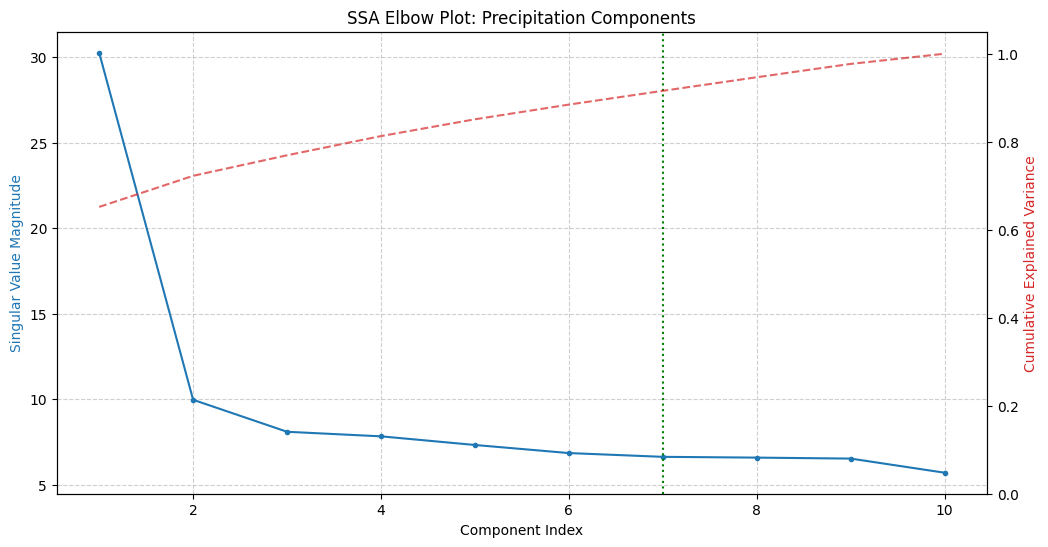

In [25]:
component_energies = np.array([np.sum(c**2) for c in components])
singular_values = np.sqrt(component_energies)

# 2. Sort them (SSA components are usually already sorted)
idx = np.argsort(singular_values)[::-1]
singular_values = singular_values[idx]

# 3. Calculate Variance Explained
total_var = np.sum(singular_values**2)
explained_variance = (singular_values**2) / total_var
cumulative_variance = np.cumsum(explained_variance)

# --- PLOTTING ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Singular Values (The Elbow)
ax1.plot(range(1, L + 1), singular_values, marker='o', markersize=3, color='tab:blue', label='Singular Values')
ax1.set_xlabel('Component Index')
ax1.set_ylabel('Singular Value Magnitude', color='tab:blue')
ax1.set_title('SSA Elbow Plot: Precipitation Components')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot Cumulative Variance (To see how much info you keep)
ax2 = ax1.twinx()
ax2.plot(range(1, L + 1), cumulative_variance, color='tab:red', linestyle='--', alpha=0.7, label='Cumulative Variance')
ax2.set_ylabel('Cumulative Explained Variance', color='tab:red')
ax2.set_ylim(0, 1.05)

# Add a vertical line at a suggested cutoff (e.g., where 90% variance is reached)
cutoff_90 = np.where(cumulative_variance >= 0.90)[0][0] + 1
ax1.axvline(x=cutoff_90, color='green', linestyle=':', label=f'90% Var ({cutoff_90} comps)')

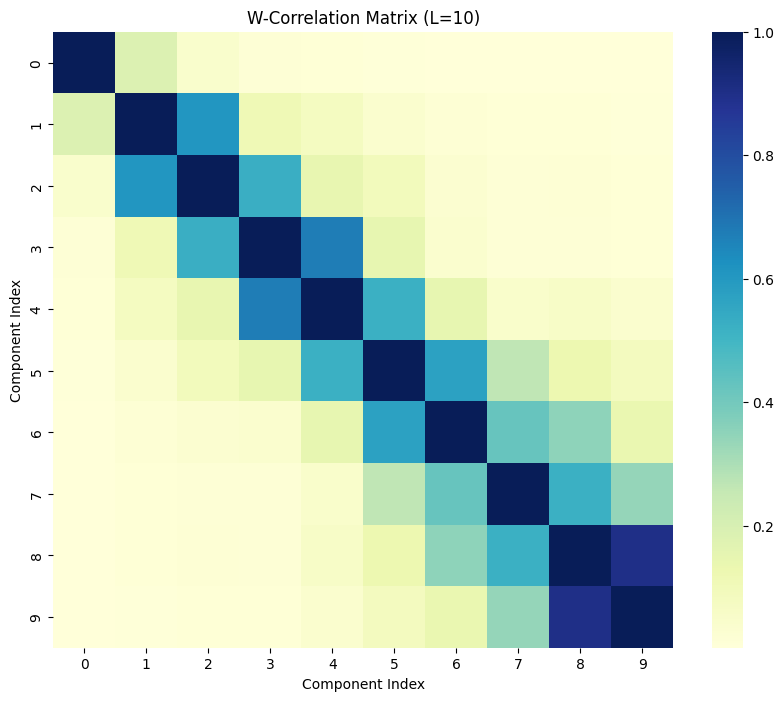

In [26]:
def plot_w_correlation(components):
    L, N = components.shape
    # Define the weights (w_i)
    # This reflects how many times each observation was used in the trajectory matrix
    K = N - L + 1
    w = np.array([min(i + 1, L, N - i) for i in range(N)])
    
    w_corr = np.zeros((L, L))
    
    # Calculate weighted norms once for efficiency
    weighted_norms = [np.sqrt(np.sum(w * (c**2))) for c in components]
    
    for i in range(L):
        for j in range(i, L):
            numerator = np.sum(w * components[i] * components[j])
            denominator = weighted_norms[i] * weighted_norms[j]
            val = abs(numerator / denominator)
            w_corr[i, j] = val
            w_corr[j, i] = val # Matrix is symmetric
            
    # Plotting
    plt.figure(figsize=(10, 8))
    sns.heatmap(w_corr, cmap='YlGnBu', annot=False)
    plt.title(f'W-Correlation Matrix (L={L})')
    plt.xlabel('Component Index')
    plt.ylabel('Component Index')
    plt.show()
    
    return w_corr

# Use it on your first 20-30 components (plotting 365 is too dense to read)
w_matrix = plot_w_correlation(components[:120])

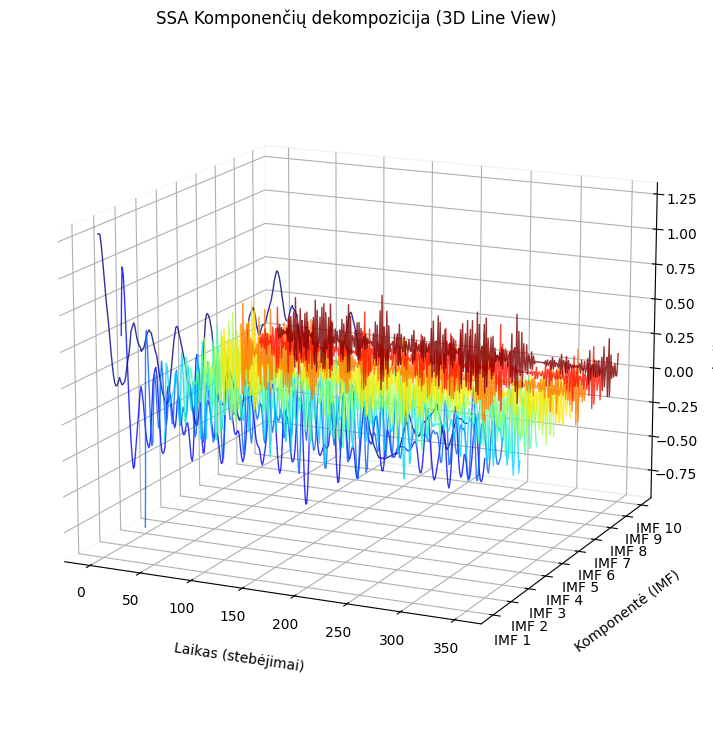

In [27]:
fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')
# Nustatome segmentą vizualizacijai (pvz., pirmos 1500 valandų)
n_points = min(350, len(train_series_explore))
x = np.arange(n_points)
zs = np.arange(N_COMP)

# Spalvų paletė
colors = plt.cm.jet(np.linspace(0, 1, N_COMP))

for i in range(N_COMP):
    y = components[i][:n_points]
    ax.plot(x, [i] * n_points, y, color=colors[i], linewidth=1, alpha=0.8)

ax.set_xlabel('Laikas (stebėjimai)', labelpad=15)
ax.set_ylabel('Komponentė (IMF)', labelpad=15)
ax.set_zlabel('Krituliai (mm)', labelpad=10)

ax.view_init(elev=15, azim=-65)

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

ax.set_yticks(zs)
ax.set_yticklabels([f'IMF {i+1}' for i in zs])

plt.title("SSA Komponenčių dekompozicija (3D Line View)")
plt.show()

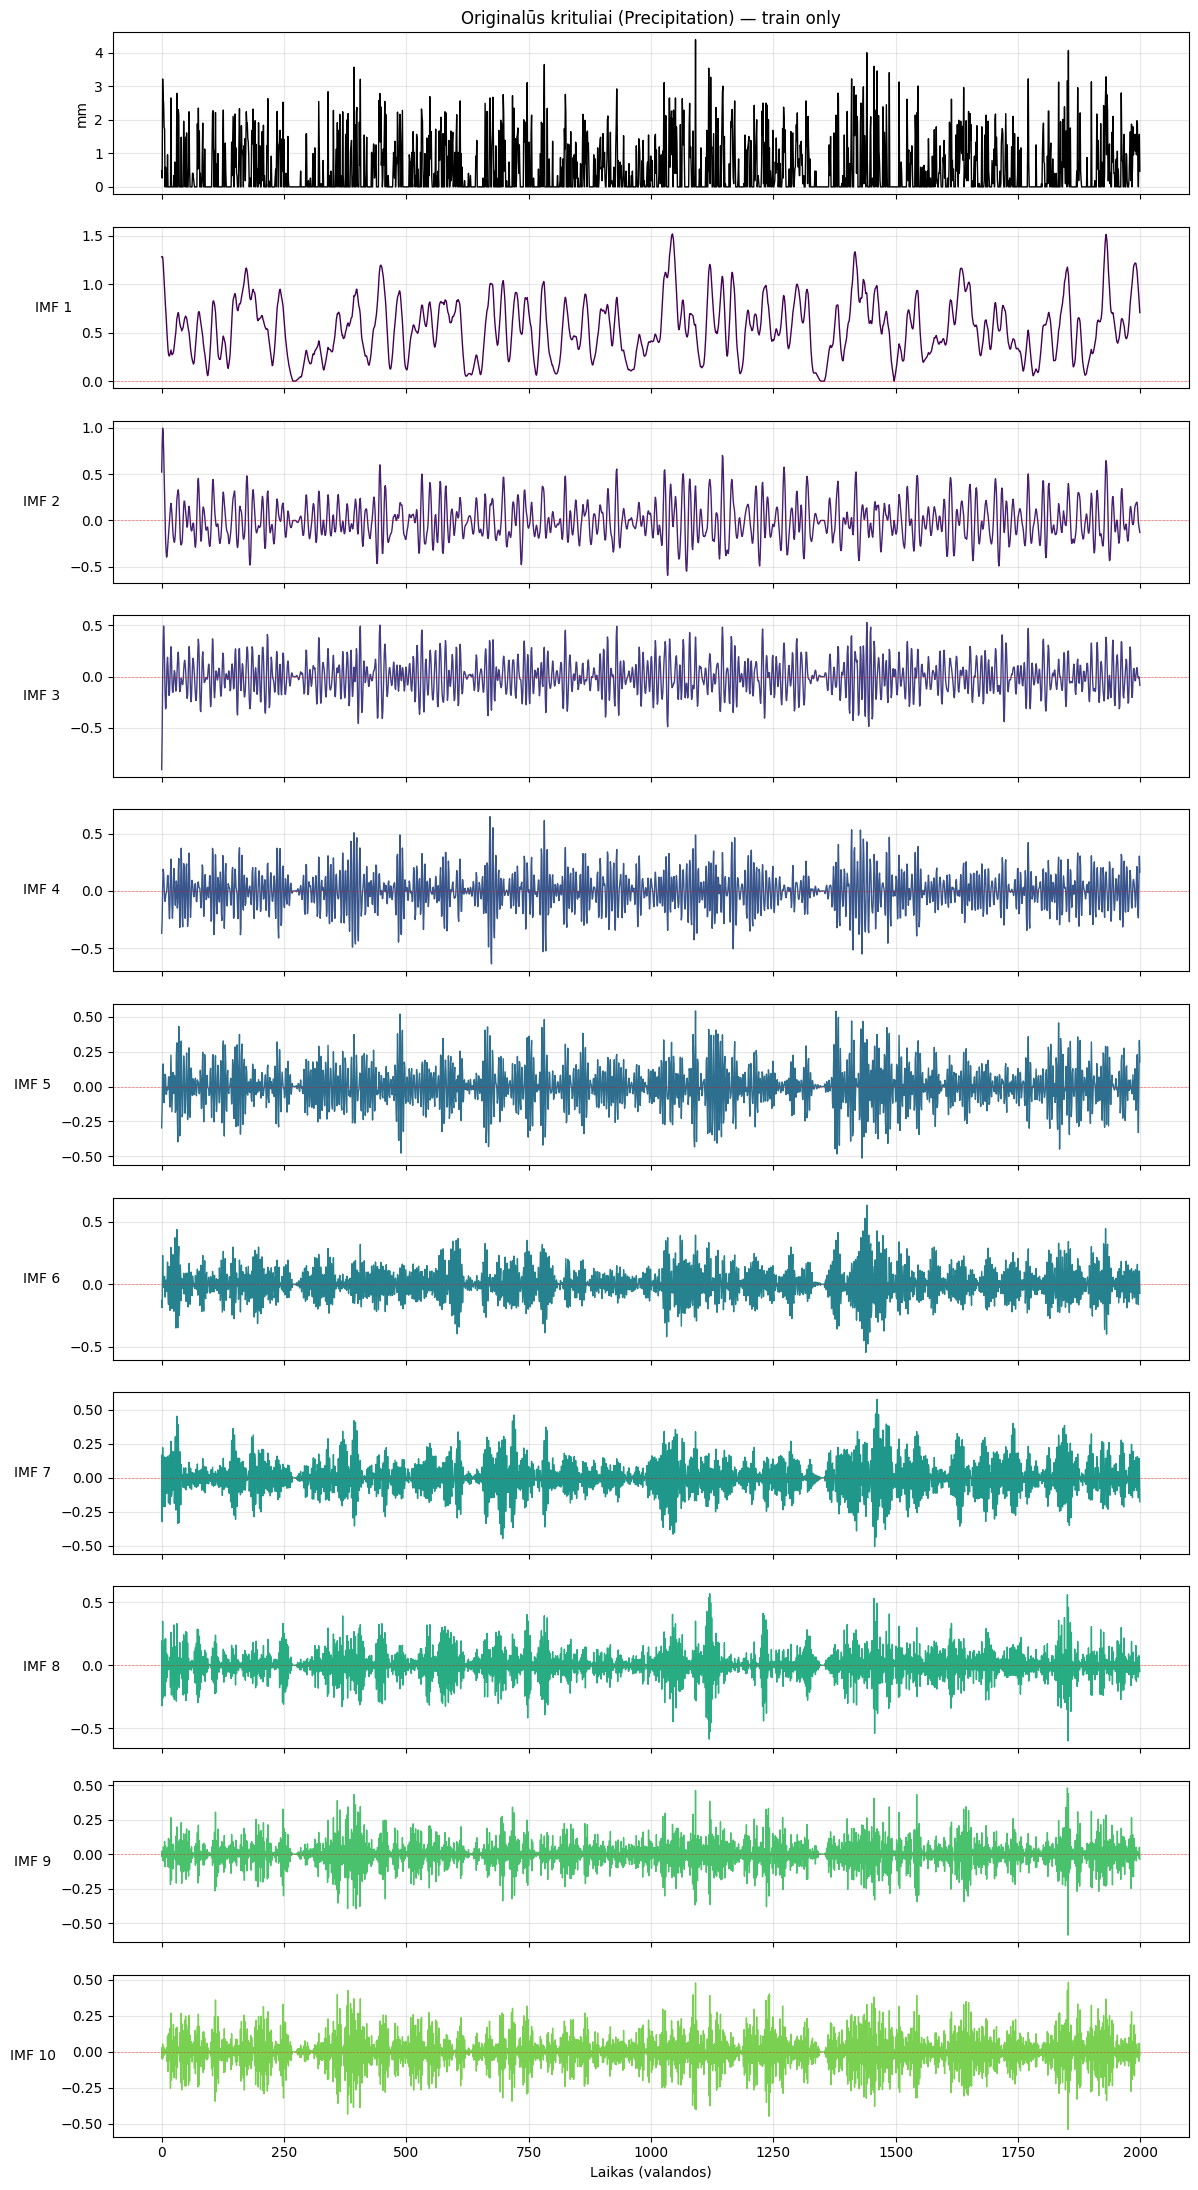

In [28]:
N = 10

fig, axes = plt.subplots(N + 1, 1, figsize=(12, 2 * (N + 1)), sharex=True)

n_points = min(2000, len(train_series_explore))
time_axis = np.arange(n_points)

# Viršutinis grafikas - Originalūs duomenys
axes[0].plot(time_axis, train_series_explore[:n_points], color='black', linewidth=1)
axes[0].set_title('Originalūs krituliai (Precipitation) — train only', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylabel('mm')

colors = plt.cm.viridis(np.linspace(0, 0.8, N))

for i in range(N):
    ax = axes[i + 1]
    ax.plot(time_axis, components[i][:n_points], color=colors[i], linewidth=1)
    ax.set_ylabel(f'IMF {i+1}', rotation=0, labelpad=20, verticalalignment='center')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='red', linestyle='--', linewidth=0.5, alpha=0.5)

axes[-1].set_xlabel('Laikas (valandos)')
plt.tight_layout()
plt.subplots_adjust(hspace=0.2)
plt.show()

In [29]:
how_group = {
    '1': [0],
    '2': [1],
    '3': [2],
    '4': [3],
    '5': [4],
    '6': [5],
    '7': [6],
    '8': [7, 8, 9],
}

# how_group = {
#     '1': [0],
#     '2': [1],
#     '3': [2],
#     '4': [3, 4],
#     '5': [5],
#     '6': [6, 7, 8, 9],
#     '7': [10, 11, 12],
#     '8': np.arange(13, 120, 1)
# }

# Build grouped components for the EXPLORATORY visualisation (train only)
grouped = []
for key in how_group:
    new_comp = np.zeros_like(components[0])
    for idx in how_group[key]:
        new_comp += components[idx]
    grouped.append(new_comp)

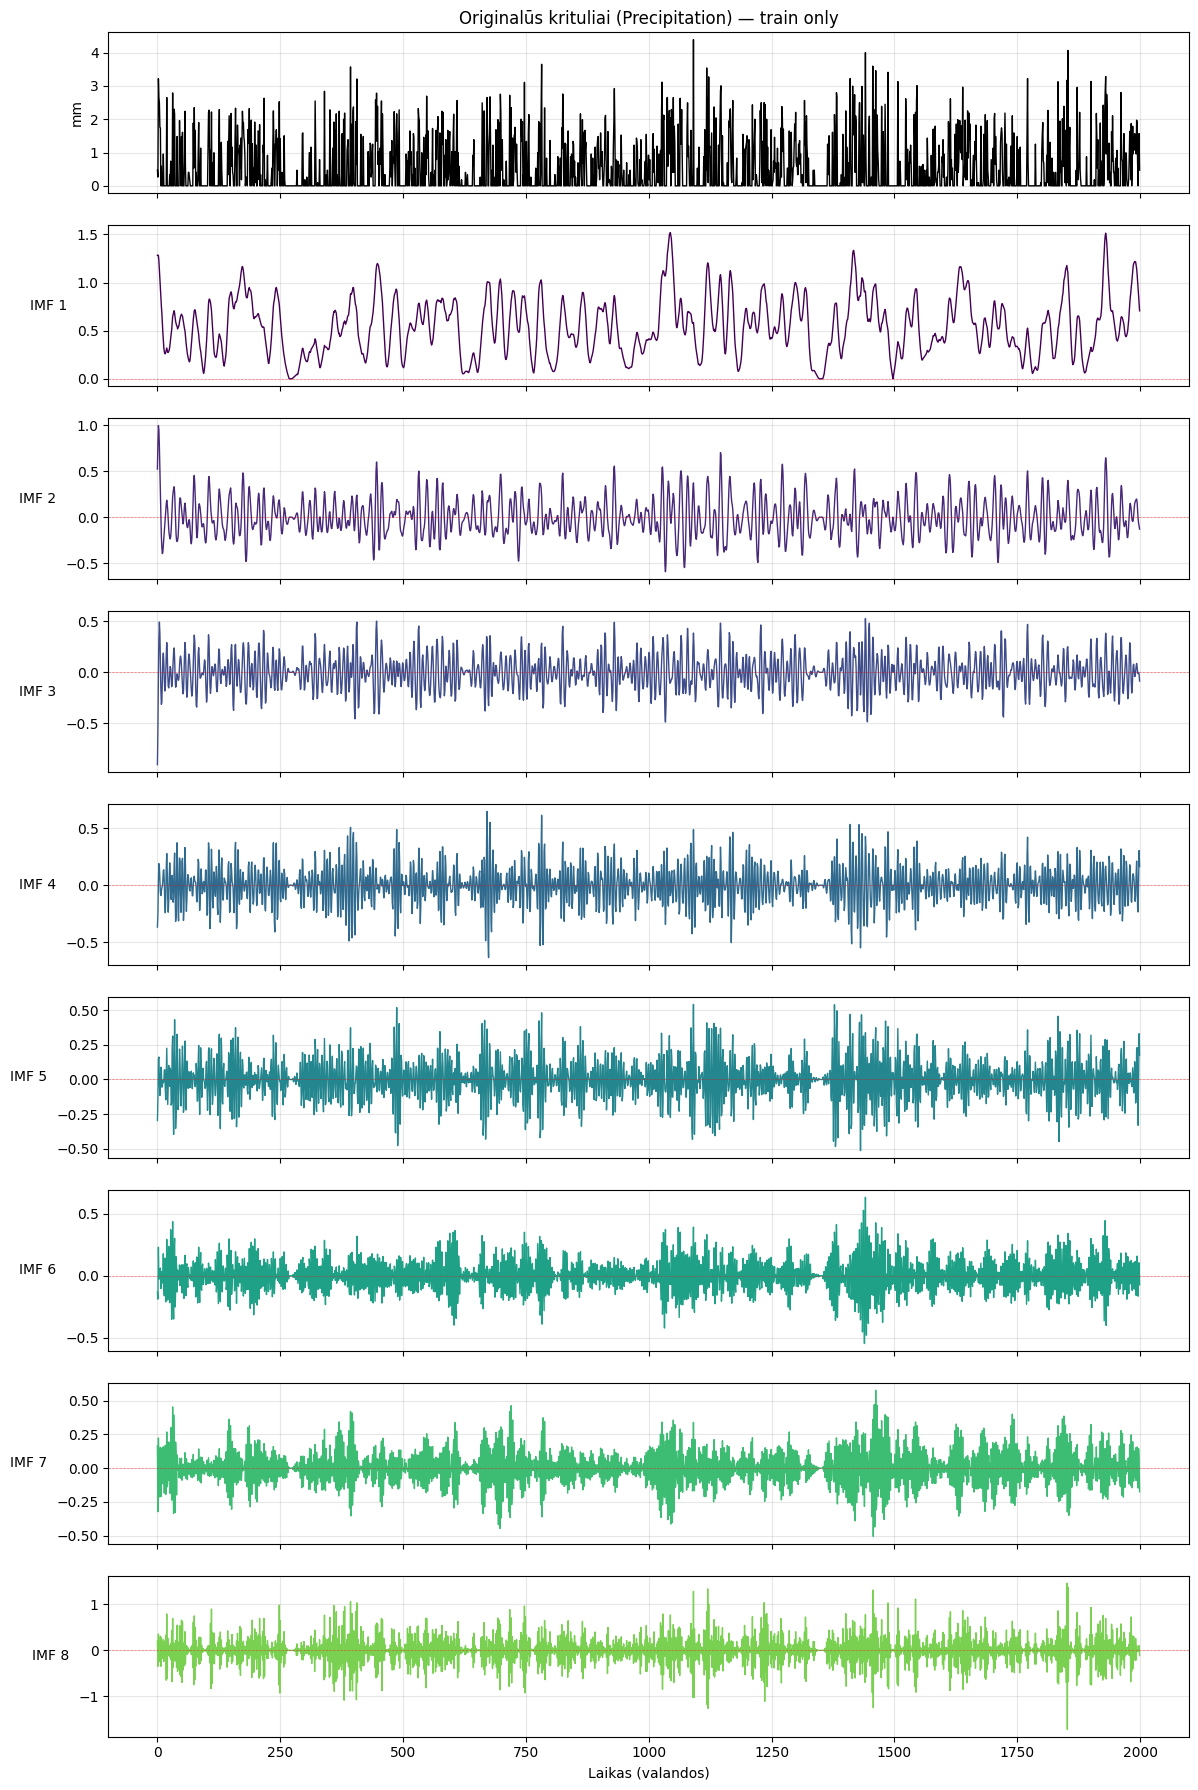

In [30]:
N = 8

fig, axes = plt.subplots(N + 1, 1, figsize=(12, 2 * (N + 1)), sharex=True)

n_points = min(2000, len(train_series_explore))
time_axis = np.arange(n_points)

# Viršutinis grafikas - Originalūs duomenys
axes[0].plot(time_axis, train_series_explore[:n_points], color='black', linewidth=1)
axes[0].set_title('Originalūs krituliai (Precipitation) — train only', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylabel('mm')

colors = plt.cm.viridis(np.linspace(0, 0.8, N))

for i in range(N):
    ax = axes[i + 1]
    ax.plot(time_axis, grouped[i][:n_points], color=colors[i], linewidth=1)
    ax.set_ylabel(f'IMF {i+1}', rotation=0, labelpad=20, verticalalignment='center')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='red', linestyle='--', linewidth=0.5, alpha=0.5)

axes[-1].set_xlabel('Laikas (valandos)')
plt.tight_layout()
plt.subplots_adjust(hspace=0.2)
plt.show()

# SSA Mokymo testavimo aibės — leakage-free

## Skirstymas

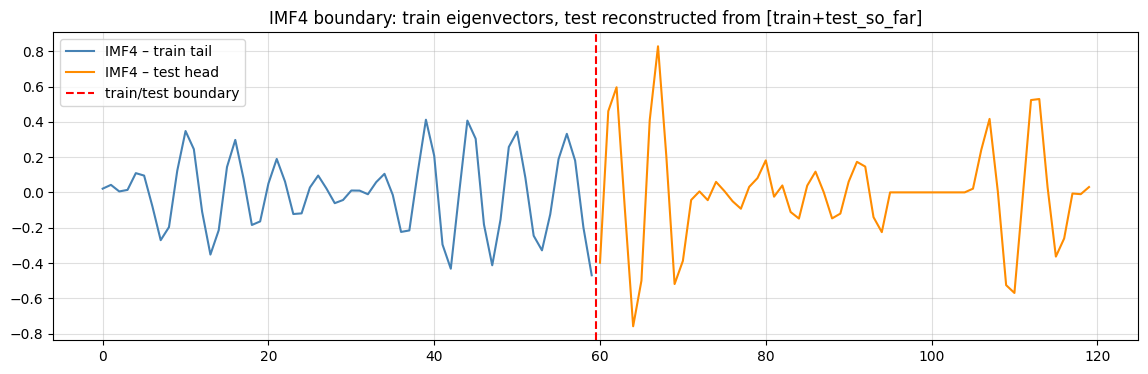

In [31]:
# ── 1. Split BEFORE any SSA ──────────────────────────────────────────────────
split_idx = int(len(X) * 0.8)
# split_idx = 2017

X_train_raw = X.iloc[:split_idx].copy()
X_test_raw  = X.iloc[split_idx:].copy()

# ── 2. Log-transform target series ───────────────────────────────────────────
train_series = np.log1p(X_train_raw['missforest_precipitation'].values)
test_series  = np.log1p(X_test_raw['missforest_precipitation'].values)

# ── 3. Fit SSA on TRAIN only ──────────────────────────────────────────────────
ssa = LeakFreeSSA(window_size=L, n_components=N_COMP)
ssa.fit(train_series)

# ── 4. Reconstruct components ─────────────────────────────────────────────────
#   Train: eigenvectors were fitted here — fully leak-free
#   Test : prepend full train for boundary context, project on TRAIN eigenvectors,
#          slice off only the test portion → no future values involved
train_components = ssa.transform_train(train_series)          # (N_COMP, N_train)
test_components  = ssa.transform_test(train_series,           # (N_COMP, N_test)
                                      test_series)

# ── 5. Group components into IMFs ─────────────────────────────────────────────
def make_grouped(components):
    grouped = []
    for key in how_group:
        new_comp = np.zeros(components.shape[1])
        for idx in how_group[key]:
            new_comp += components[idx]
        grouped.append(new_comp)
    return grouped

train_grouped = make_grouped(train_components)
test_grouped  = make_grouped(test_components)

# ── 6. Assign IMF columns back into the split DataFrames ─────────────────────
for i, key in enumerate(how_group):
    X_train_raw[f'IMF{i+1}'] = train_grouped[i]
    X_test_raw[f'IMF{i+1}']  = test_grouped[i]

# ── 7. Boundary sanity check ──────────────────────────────────────────────────
n_ctx = 60
plt.figure(figsize=(14, 4))
plt.plot(np.arange(n_ctx), train_grouped[3][-n_ctx:],
         linewidth=1.5, label='IMF4 – train tail', color='steelblue')
plt.plot(np.arange(n_ctx, 2*n_ctx), test_grouped[3][:n_ctx],
         linewidth=1.5, label='IMF4 – test head', color='darkorange')
plt.axvline(x=n_ctx - 0.5, color='red', linestyle='--', label='train/test boundary')
plt.title('IMF4 boundary: train eigenvectors, test reconstructed from [train+test_so_far]')
plt.legend(); plt.grid(True, alpha=0.4); plt.show()

In [32]:
def rolling_window_fun(column_name, window_value, data):
    new_col_name = f"{column_name}_mean_{window_value}"
    data.loc[:, new_col_name] = data[column_name].rolling(window=window_value).mean()

def rolling_max(column_name, window_value, data):
    new_col_name = f"{column_name}_max_{window_value}"
    data.loc[:, new_col_name] = data[column_name].rolling(window=window_value).max()

def rolling_min(column_name, window_value, data):
    new_col_name = f"{column_name}_max_{window_value}"
    data.loc[:, new_col_name] = data[column_name].rolling(window=window_value).min()

In [33]:
data.columns

Index(['observationTime', 'absorbing_aerosol_index',
       'NO2_column_number_density', 'stratospheric_NO2_column_number_density',
       'NO2_slant_column_number_density', 'tropopause_pressure',
       'H2O_column_number_density', 'BrO', 'BrO_Error', 'NO2', 'NO2_Error',
       'O3', 'O3_Error', 'pm10', 'pm2p5', 'sia', 'nmvoc', 'dust', 'nh3',
       'pans', 'tp', 't2m', 'airTemperature', 'seaLevelPressure',
       'relativeHumidity', 'missforest_precipitation', 'xgb_cloudCover',
       'feelsLikeTemperature_fixed', 'windSpeed_fixed', 'windGust_fixed',
       'windDirection_fixed', 'month', 'day_of_year', 'day_of_week',
       'month_sin', 'month_cos', 'airTemperature_lag1', 'airTemperature_lag3',
       'airTemperature_lag9', 'airTemperature_lag10', 'seaLevelPressure_lag1',
       'seaLevelPressure_lag2', 'relativeHumidity_lag1',
       'relativeHumidity_lag2', 'xgb_cloudCover_lag1', 'xgb_cloudCover_lag2',
       'windSpeed_fixed_lag1', 'windSpeed_fixed_lag2', 'windSpeed_fixed_lag3',


In [34]:
window_info = {
    'airTemperature': [7],
    'relativeHumidity': [7],
    'seaLevelPressure': [7],
}

for df in [X_train_raw, X_test_raw]:
    for col, windows in window_info.items():
        if isinstance(windows, list):
            for window in windows:
                rolling_max(col, window, df)
        else:
            rolling_max(col, windows, df)

for df in [X_train_raw, X_test_raw]:
    for col, windows in window_info.items():
        if isinstance(windows, list):
            for window in windows:
                rolling_min(col, window, df)
        else:
            rolling_min(col, windows, df)

all_data = pd.concat([X_train_raw, X_test_raw])

for i in range(1, 9):
    all_data[f'IMF{i}_diff'] = all_data[f'IMF{i}'].diff()

X_train_raw = all_data.iloc[:len(X_train_raw)].copy().dropna()
X_test_raw = all_data.iloc[len(X_train_raw):].copy()

X_train_raw = X_train_raw.dropna()
X_test_raw  = X_test_raw.dropna()

In [35]:
IMF_COLS = ['IMF1', 'IMF2', 'IMF3_diff', 'IMF4_diff', 'IMF5', 'IMF6_diff', 'IMF7', 'IMF8']
IMF_COLS_true = ['IMF1', 'IMF2', 'IMF3', 'IMF4', 'IMF5', 'IMF6', 'IMF7', 'IMF8']

y_train = X_train_raw[IMF_COLS]
y_test  = X_test_raw[IMF_COLS]
y_original_imf = X_test_raw[IMF_COLS_true]

In [36]:
# Predict next day: X[t] → y[t+1]
# X_train = X_train_raw[:-1].drop(columns=['observationTime'], errors='ignore')
# y_train = y_train.iloc[1:]

X_train = X_train_raw[:].drop(columns=['observationTime'], errors='ignore')
y_train = y_train.iloc[:]

In [37]:
# X_test = X_test_raw[:-1].drop(columns=['observationTime'], errors='ignore')
# y_test = y_test.iloc[1:]

X_test = X_test_raw[:].drop(columns=['observationTime'], errors='ignore')
y_test = y_test.iloc[:]

In [38]:
# Scaler fitted on TRAIN only, applied to both
sklearn.set_config(transform_output="pandas")
scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test  = scaler.transform(X_test)

## IMF1

In [121]:
featues_imf1 = select_features_lasso(X_train, 'IMF1', -0.001)[:-1]
featues_imf1

Pradinis požymių skaičius: 52
Išlikusių požymių skaičius: 44
Geriausias lambda (alpha): 0.0010
Pašalinti požymiai: ['IMF6', 'IMF8', 'IMF2', 'IMF7', 'IMF4', 'IMF3_diff', 'IMF5_diff', 'IMF8_diff']


['tp',
 't2m',
 'airTemperature',
 'seaLevelPressure',
 'relativeHumidity',
 'missforest_precipitation',
 'xgb_cloudCover',
 'feelsLikeTemperature_fixed',
 'windSpeed_fixed',
 'windGust_fixed',
 'windDirection_fixed',
 'month',
 'day_of_year',
 'day_of_week',
 'month_sin',
 'month_cos',
 'airTemperature_lag1',
 'airTemperature_lag3',
 'airTemperature_lag9',
 'airTemperature_lag10',
 'seaLevelPressure_lag1',
 'seaLevelPressure_lag2',
 'relativeHumidity_lag1',
 'relativeHumidity_lag2',
 'xgb_cloudCover_lag1',
 'xgb_cloudCover_lag2',
 'windSpeed_fixed_lag1',
 'windSpeed_fixed_lag2',
 'windSpeed_fixed_lag3',
 'windGust_fixed_lag1',
 'windGust_fixed_lag2',
 'windDirection_fixed_lag4',
 'windDirection_fixed_lag10',
 'IMF3',
 'IMF5',
 'airTemperature_max_7',
 'relativeHumidity_max_7',
 'seaLevelPressure_max_7',
 'IMF1_diff',
 'IMF2_diff',
 'IMF4_diff',
 'IMF6_diff',
 'IMF7_diff']

In [122]:
# featues_imf1.extend(['tp', 'missforest_precipitation'])
X_train_IMF1 = X_train[featues_imf1]
X_test_IMF1 = X_test[featues_imf1]

## IMF2

In [49]:
featues_imf2 = select_features_lasso(X_train, 'IMF2', 0.001)[:-1]
featues_imf2

Pradinis požymių skaičius: 52
Išlikusių požymių skaičius: 10
Geriausias lambda (alpha): 0.0009
Pašalinti požymiai: ['windGust_fixed', 'IMF7_diff', 'day_of_week', 'day_of_year', 'seaLevelPressure_lag2', 'IMF6_diff', 'tp', 'month_cos', 'month_sin', 'relativeHumidity_lag1', 't2m', 'xgb_cloudCover', 'relativeHumidity_max_7', 'IMF7', 'airTemperature_lag10', 'airTemperature_lag1', 'windSpeed_fixed', 'feelsLikeTemperature_fixed', 'airTemperature_lag3', 'windGust_fixed_lag2', 'IMF8', 'windSpeed_fixed_lag2', 'IMF4_diff', 'seaLevelPressure_max_7', 'seaLevelPressure_lag1', 'windDirection_fixed_lag4', 'windDirection_fixed_lag10', 'airTemperature', 'IMF3', 'missforest_precipitation', 'airTemperature_max_7', 'month', 'xgb_cloudCover_lag2', 'xgb_cloudCover_lag1', 'relativeHumidity_lag2', 'windSpeed_fixed_lag1', 'windDirection_fixed', 'windGust_fixed_lag1', 'IMF5', 'windSpeed_fixed_lag3', 'relativeHumidity', 'seaLevelPressure']


['airTemperature_lag9',
 'IMF1',
 'IMF4',
 'IMF6',
 'IMF1_diff',
 'IMF2_diff',
 'IMF3_diff',
 'IMF5_diff',
 'IMF8_diff']

In [50]:
X_train_IMF2 = X_train[featues_imf2]
X_test_IMF2 = X_test[featues_imf2]

## IMF3

In [51]:
featues_imf3 = select_features_lasso(X_train, 'IMF3_diff', 0.00001)
featues_imf3

Pradinis požymių skaičius: 52
Išlikusių požymių skaičius: 12
Geriausias lambda (alpha): 0.0008
Pašalinti požymiai: ['windGust_fixed', 'airTemperature_lag9', 'IMF7_diff', 'IMF5_diff', 'day_of_year', 'IMF1', 'seaLevelPressure_lag2', 'month_cos', 'month_sin', 'IMF6', 'relativeHumidity_lag1', 't2m', 'xgb_cloudCover', 'relativeHumidity_max_7', 'IMF1_diff', 'IMF7', 'airTemperature_lag10', 'airTemperature_lag1', 'feelsLikeTemperature_fixed', 'airTemperature_lag3', 'windGust_fixed_lag2', 'IMF8', 'windSpeed_fixed_lag2', 'seaLevelPressure_max_7', 'seaLevelPressure_lag1', 'IMF4', 'windDirection_fixed_lag4', 'windDirection_fixed_lag10', 'airTemperature', 'IMF8_diff', 'IMF3', 'missforest_precipitation', 'airTemperature_max_7', 'xgb_cloudCover_lag2', 'xgb_cloudCover_lag1', 'relativeHumidity_lag2', 'windSpeed_fixed_lag1', 'windGust_fixed_lag1', 'windSpeed_fixed_lag3', 'seaLevelPressure']


['tp',
 'relativeHumidity',
 'windSpeed_fixed',
 'windDirection_fixed',
 'month',
 'day_of_week',
 'IMF2',
 'IMF5',
 'IMF2_diff',
 'IMF4_diff',
 'IMF6_diff',
 'IMF3_diff']

In [52]:
X_train_IMF3 = X_train[featues_imf3]
X_test_IMF3 = X_test[featues_imf3]

## IMF4

In [53]:
featues_imf4 = select_features_lasso(X_train, 'IMF4_diff', -0.000000001)[:-1]
featues_imf4

Pradinis požymių skaičius: 52
Išlikusių požymių skaičius: 34
Geriausias lambda (alpha): 0.0005
Pašalinti požymiai: ['month', 'IMF8', 'windGust_fixed', 'xgb_cloudCover', 'IMF2', 'IMF7', 'IMF4', 'windDirection_fixed_lag10', 'day_of_week', 'windDirection_fixed', 'windSpeed_fixed', 'windGust_fixed_lag1', 'IMF2_diff', 'IMF5', 'relativeHumidity', 'seaLevelPressure_lag2', 'IMF6_diff', 'tp']


['t2m',
 'airTemperature',
 'seaLevelPressure',
 'missforest_precipitation',
 'feelsLikeTemperature_fixed',
 'day_of_year',
 'month_sin',
 'month_cos',
 'airTemperature_lag1',
 'airTemperature_lag3',
 'airTemperature_lag9',
 'airTemperature_lag10',
 'seaLevelPressure_lag1',
 'relativeHumidity_lag1',
 'relativeHumidity_lag2',
 'xgb_cloudCover_lag1',
 'xgb_cloudCover_lag2',
 'windSpeed_fixed_lag1',
 'windSpeed_fixed_lag2',
 'windSpeed_fixed_lag3',
 'windGust_fixed_lag2',
 'windDirection_fixed_lag4',
 'IMF1',
 'IMF3',
 'IMF6',
 'airTemperature_max_7',
 'relativeHumidity_max_7',
 'seaLevelPressure_max_7',
 'IMF1_diff',
 'IMF3_diff',
 'IMF5_diff',
 'IMF7_diff',
 'IMF8_diff']

In [54]:
X_train_IMF4 = X_train[featues_imf4]
X_test_IMF4 = X_test[featues_imf4]

## IMF5

In [56]:
featues_imf5 = select_features_lasso(X_train, 'IMF5')[:-1]
featues_imf5

Pradinis požymių skaičius: 52
Išlikusių požymių skaičius: 17
Geriausias lambda (alpha): 0.0009
Pašalinti požymiai: ['seaLevelPressure', 'airTemperature_lag9', 'IMF7_diff', 'day_of_year', 'IMF1', 'seaLevelPressure_lag2', 'month_cos', 'month_sin', 'IMF6', 't2m', 'xgb_cloudCover', 'relativeHumidity_max_7', 'IMF1_diff', 'IMF7', 'airTemperature_lag10', 'airTemperature_lag1', 'feelsLikeTemperature_fixed', 'airTemperature_lag3', 'IMF8', 'seaLevelPressure_max_7', 'seaLevelPressure_lag1', 'windDirection_fixed_lag4', 'airTemperature', 'IMF8_diff', 'IMF3', 'missforest_precipitation', 'airTemperature_max_7', 'relativeHumidity_lag2', 'IMF3_diff', 'windSpeed_fixed_lag1', 'windGust_fixed_lag1', 'IMF5', 'windSpeed_fixed_lag3', 'relativeHumidity', 'windSpeed_fixed_lag2']


['tp',
 'windSpeed_fixed',
 'windGust_fixed',
 'windDirection_fixed',
 'month',
 'day_of_week',
 'relativeHumidity_lag1',
 'xgb_cloudCover_lag1',
 'xgb_cloudCover_lag2',
 'windGust_fixed_lag2',
 'windDirection_fixed_lag10',
 'IMF2',
 'IMF4',
 'IMF2_diff',
 'IMF4_diff',
 'IMF5_diff']

In [57]:
X_train_IMF5 = X_train[featues_imf5]
X_test_IMF5 = X_test[featues_imf5]

## IMF6

In [58]:
featues_imf6 = select_features_lasso(X_train, 'IMF6_diff')
featues_imf6

Pradinis požymių skaičius: 52
Išlikusių požymių skaičius: 17
Geriausias lambda (alpha): 0.0008
Pašalinti požymiai: ['windGust_fixed', 'IMF2', 'airTemperature_lag9', 'IMF7_diff', 'day_of_week', 'day_of_year', 'seaLevelPressure_lag2', 'month_cos', 'month_sin', 'IMF6', 'relativeHumidity_lag1', 't2m', 'IMF7', 'airTemperature_lag1', 'windSpeed_fixed', 'feelsLikeTemperature_fixed', 'airTemperature_lag3', 'windGust_fixed_lag2', 'IMF8', 'seaLevelPressure_max_7', 'seaLevelPressure_lag1', 'IMF4', 'windDirection_fixed_lag4', 'windDirection_fixed_lag10', 'airTemperature', 'missforest_precipitation', 'airTemperature_max_7', 'month', 'xgb_cloudCover_lag2', 'xgb_cloudCover_lag1', 'relativeHumidity_lag2', 'windDirection_fixed', 'IMF2_diff', 'relativeHumidity', 'IMF4_diff']


['tp',
 'seaLevelPressure',
 'xgb_cloudCover',
 'airTemperature_lag10',
 'windSpeed_fixed_lag1',
 'windSpeed_fixed_lag2',
 'windSpeed_fixed_lag3',
 'windGust_fixed_lag1',
 'IMF1',
 'IMF3',
 'IMF5',
 'relativeHumidity_max_7',
 'IMF1_diff',
 'IMF3_diff',
 'IMF5_diff',
 'IMF8_diff',
 'IMF6_diff']

In [59]:
X_train_IMF6 = X_train[featues_imf6]
X_test_IMF6 = X_test[featues_imf6]

## IMF7

In [61]:
featues_imf7 = select_features_lasso(X_train, 'IMF7', -0.000001)[:-1]
featues_imf7

Pradinis požymių skaičius: 52
Išlikusių požymių skaičius: 31
Geriausias lambda (alpha): 0.0011
Pašalinti požymiai: ['airTemperature_lag9', 'IMF5_diff', 'day_of_year', 'IMF1', 'month_cos', 'relativeHumidity_lag1', 'IMF7', 'feelsLikeTemperature_fixed', 'windGust_fixed_lag2', 'IMF8', 'seaLevelPressure_max_7', 'seaLevelPressure_lag1', 'windDirection_fixed_lag4', 'windDirection_fixed_lag10', 'IMF3', 'missforest_precipitation', 'xgb_cloudCover_lag2', 'relativeHumidity_lag2', 'IMF3_diff', 'windSpeed_fixed_lag1', 'IMF5']


['tp',
 't2m',
 'airTemperature',
 'seaLevelPressure',
 'relativeHumidity',
 'xgb_cloudCover',
 'windSpeed_fixed',
 'windGust_fixed',
 'windDirection_fixed',
 'month',
 'day_of_week',
 'month_sin',
 'airTemperature_lag1',
 'airTemperature_lag3',
 'airTemperature_lag10',
 'seaLevelPressure_lag2',
 'xgb_cloudCover_lag1',
 'windSpeed_fixed_lag2',
 'windSpeed_fixed_lag3',
 'windGust_fixed_lag1',
 'IMF2',
 'IMF4',
 'IMF6',
 'airTemperature_max_7',
 'relativeHumidity_max_7',
 'IMF1_diff',
 'IMF2_diff',
 'IMF4_diff',
 'IMF6_diff',
 'IMF7_diff']

In [62]:
X_train_IMF7 = X_train[featues_imf7]
X_test_IMF7 = X_test[featues_imf7]

## IMF8

In [63]:
featues_imf8 = select_features_lasso(X_train, 'IMF8')[:-1]
featues_imf8

Pradinis požymių skaičius: 52
Išlikusių požymių skaičius: 22
Geriausias lambda (alpha): 0.0007
Pašalinti požymiai: ['airTemperature_lag9', 'IMF7_diff', 'IMF5_diff', 'day_of_year', 'IMF1', 'month_cos', 'month_sin', 'relativeHumidity_lag1', 't2m', 'xgb_cloudCover', 'IMF1_diff', 'feelsLikeTemperature_fixed', 'airTemperature_lag3', 'windGust_fixed_lag2', 'IMF8', 'seaLevelPressure_max_7', 'seaLevelPressure_lag1', 'windDirection_fixed_lag4', 'windDirection_fixed_lag10', 'airTemperature', 'IMF3', 'missforest_precipitation', 'airTemperature_max_7', 'month', 'xgb_cloudCover_lag2', 'relativeHumidity_lag2', 'IMF3_diff', 'windSpeed_fixed_lag1', 'windDirection_fixed', 'IMF5']


['tp',
 'seaLevelPressure',
 'relativeHumidity',
 'windSpeed_fixed',
 'windGust_fixed',
 'day_of_week',
 'airTemperature_lag1',
 'airTemperature_lag10',
 'seaLevelPressure_lag2',
 'xgb_cloudCover_lag1',
 'windSpeed_fixed_lag2',
 'windSpeed_fixed_lag3',
 'windGust_fixed_lag1',
 'IMF2',
 'IMF4',
 'IMF6',
 'IMF7',
 'relativeHumidity_max_7',
 'IMF2_diff',
 'IMF4_diff',
 'IMF6_diff']

In [64]:
X_train_IMF8 = X_train[featues_imf8]
X_test_IMF8 = X_test[featues_imf8]

# LSTM

In [65]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (batch, time, features)
        out, _ = self.lstm(x)
        last_step = out[:, -1, :]
        return self.fc(last_step)

In [66]:
class SequenceScaler:
    """Standartizuoja X ir suformuoja sliding window sekas."""
    def __init__(self, window_size):
        self.window_size = window_size
        self.scaler = StandardScaler()
        # self.scaler = MinMaxScaler()

    def fit(self, X):
        self.scaler.fit(X)
        return self

    def transform(self, X):
        X_scaled = self.scaler.transform(X)
        X_seq = []
        for i in range(len(X_scaled) - self.window_size):
            X_seq.append(X_scaled[i:i + self.window_size])
        return np.array(X_seq)

In [67]:
class TweedieLoss(nn.Module):
    """
    Tweedie loss su log-link.
    Reikalauja: target >= 0  (krituliai visada >= 0 ✓)

    LSTM output pred — neribojamas (log erdvė)
    μ = exp(pred) > 0  (nereikia aktyvacijos)

    Gradientas dL/d(pred) = -y·μ^(1-p) + μ^(2-p)
    Kai y=15: gradientas ~20x didesnis nei kai y=0.5
    → modelis stipriai baudžiamas už šuolių praleidimą
    """
    def __init__(self, p=1.5):
        super().__init__()
        assert 1 < p < 2
        self.p = p

    def forward(self, pred, target):
        pred   = pred.squeeze(-1)
        target = target.squeeze(-1)
        mu = torch.exp(pred)
        p  = self.p
        return (-target * mu.pow(1 - p) / (1 - p) + mu.pow(2 - p) / (2 - p)).mean()

In [68]:
class LSTMNet(NeuralNetRegressor):
    def __init__(self, base_module, window_size=10, **net_params):
        self.base_module = base_module
        self.window_size = window_size
        if 'module' not in net_params:
            net_params['module'] = base_module

        super().__init__(**net_params)

    # def __sklearn_tags__(self):
    #     return {"estimator_type": "regressor"}

    # def fit(self, X, y, **fit_params):
    #     ws = self.window_size

    #     # 1. Features: sliding window sekos
    #     self.seq = SequenceScaler(window_size=ws)
    #     self.seq.fit(X)
    #     X_seq = self.seq.transform(X)        # (N-ws, ws, F)

    #     # 2. Target standartizacija
    #     # self.y_scaler = StandardScaler()
    #     # y_scaled = self.y_scaler.fit_transform(y.reshape(-1, 1)).ravel()  # (N,)
    #     y_scaled = y.reshape(-1, 1)

    #     # 3. Alignment: X_seq[j] -> window [j, j+ws), target = y[j+ws]
    #     y_trunc = y_scaled[ws:]              # (N-ws,)

    #     # 4. Vienas LSTM visam targetui
    #     self.model = NeuralNetRegressor(
    #         module=self.base_module,
    #         module__input_dim=X_seq.shape[2],
    #         train_split=ValidSplit(0.2),
    #         callbacks=[
    #             Checkpoint(monitor='valid_loss_best', load_best=True),
    #             EarlyStopping(patience=20)
    #         ],
    #         **self.net_params
    #     )
    #     self.model.fit(X_seq.astype(np.float32), y_trunc.astype(np.float32))
    #     return self
    
    def fit(self, X, y, **fit_params):
        torch.manual_seed(42)
        np.random.seed(42)
        ws = self.window_size

        # 1. Paruošiame sekas (naudojame self.window_size, kurį GridSearch keis)
        self.seq = SequenceScaler(window_size=ws)
        self.seq.fit(X)
        X_seq = self.seq.transform(X)        # (N-ws, ws, F)

        # 2. Target paruošimas (suvienodiname ilgį su X_seq)
        y_trunc = y[ws:].reshape(-1, 1)      # (N-ws, 1)

        # 3. Konvertuojame į float32 (būtina PyTorch)
        X_seq = X_seq.astype(np.float32)
        y_trunc = y_trunc.astype(np.float32)

        # 4. SVARBU: Atnaujiname modelio parametrus prieš treniravimą
        # Kadangi paveldime iš NeuralNetRegressor, parametrai nustatomi per self.set_params
        self.set_params(module__input_dim=X_seq.shape[2])
        
        # Pridedame EarlyStopping ir kitus callbacks, jei jų dar nėra
        if 'callbacks' not in self.get_params():
             self.set_params(callbacks=[
                Checkpoint(monitor='valid_loss_best', load_best=True),
                EarlyStopping(patience=5)
            ])

        # 5. Kviečiame bazinį skorch fit su apdorotais duomenimis
        # Tai leis GridSearchCV matyti progresą ir skaičiuoti score
        return super().fit(X_seq, y_trunc, **fit_params)
    
    def predict(self, X):
        # 1. Paruošiame sekas iš X_test naudojant fit metu sukurtą seq objektą
        X_seq = self.seq.transform(X)        # (M-ws, ws, F)
        
        # 2. Kviečiame bazinį skorch predict metodą
        # Nebenaudojame self.model.predict, o naudojame super().predict
        y_scaled_pred = super().predict(X_seq.astype(np.float32))
        
        # 3. Grąžiname rezultatą (be de-standartizacijos, jei jos nenaudoji)
        return y_scaled_pred.reshape(-1, 1)

In [69]:
class LSTMFCRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Vietoj vieno fc sluoksnio, naudojame Sequential bloką su LeakyReLU.
        # Tai padeda modeliui "ištraukti" triukšmo pikus, kurių paprastas fc nepagautų.
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.1), 
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        # Naudojame paskutinį laiko žingsnį
        return self.fc(out[:, -1, :])

# SSA-LSTM
## IMF1

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 7}

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 3}

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.4, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 1}

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.4, 'module__hidden_dim': 256, 'module__num_layers': 2, 'window_size': 3}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 256, 'module__num_layers': 1, 'window_size': 5}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 3}

In [123]:
pipeline = LSTMNet(
    base_module=LSTMRegressor,
    window_size=14,

    module__hidden_dim=128,
    module__num_layers=2,
    module__dropout=0.3,
    optimizer__weight_decay = 0,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=15, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=750,
    lr=0.001,
    batch_size=32,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=1),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [124]:
pipeline.fit(X_train_IMF1.values, y_train['IMF1'].values)
pred = pipeline.predict(X_test_IMF1.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0566        0.0169     +  0.3926
      2        0.0131        0.0086     +  0.2857
      3        0.0092        0.0155        0.2818
      4        0.0084        0.0091        0.2722
      5        0.0066        0.0081     +  0.2794
      6        0.0055        0.0080     +  0.2851
      7        0.0060        0.0129        0.2719
      8        0.0072        0.0079     +  0.2940
      9        0.0071        0.0098        0.3028
     10        0.0099        0.0108        0.2798
     11        0.0091        0.0109        0.2964
     12        0.0052        0.0072     +  0.2981
     13        0.0029        0.0057     +  0.2981
     14        0.0023        0.0055     +  0.2938
     15        0.0023        0.0049     +  0.2840
     16        0.0025        0.0056        0.2874
     17        0.0026        0.0052        0.2862
     18        0.0027        0.0093        0.2721


In [108]:
param_grid = {
    'window_size': [2, 3, 5],
    'module__hidden_dim': [128],
    'module__num_layers': [1, 2, 3],
    'lr': [0.001, 0.005],
    'module__dropout': [0.3],
    'batch_size': [32],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF1.values, y_train['IMF1'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF1.values)

Fitting 2 folds for each of 18 candidates, totalling 36 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.1047        0.0361     +  0.2143
      2        0.0377        0.0192     +  0.1791
      3        0.0195        0.0230        0.1234
      4        0.0153        0.0188     +  0.0974
      5        0.0140        0.0194        0.0939
      6        0.0130        0.0186     +  0.0923
      7        0.0121        0.0178     +  0.0721
      8        0.0112        0.0173     +  0.0618
      9        0.0105        0.0168     +  0.0599
     10        0.0098        0.0163     +  0.0596
     11        0.0093        0.0158     +  0.0595
     12        0.0087        0.0153     +  0.0643
     13        0.0083        0.0148     +  0.0580
     14        0.0079        0.0144     +  0.0582
     15        0.0076        0.0140     +  0.0567
     16        0.0074        0.0136     +  0.0570
     17        0.0071        0.0132    

In [129]:
y_true = y_test['IMF1'].values.astype(float)
# y_true = np.expm1(y_true)

y_true =  y_true[14:]
y_pred = np.array(pred).reshape(-1)[:]
# y_pred = np.expm1(y_pred)

# Sulygiuojame ilgius
# min_len = min(len(y_true), len(y_pred))
# y_true = y_true[:min_len]
# y_pred = y_pred[:min_len]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF1 = y_true[:]
y_pred_IMF1 = y_pred[:]


RMSE:     0.1736
MAE:      0.1349
R2:       0.7265
Spearman: 0.9089


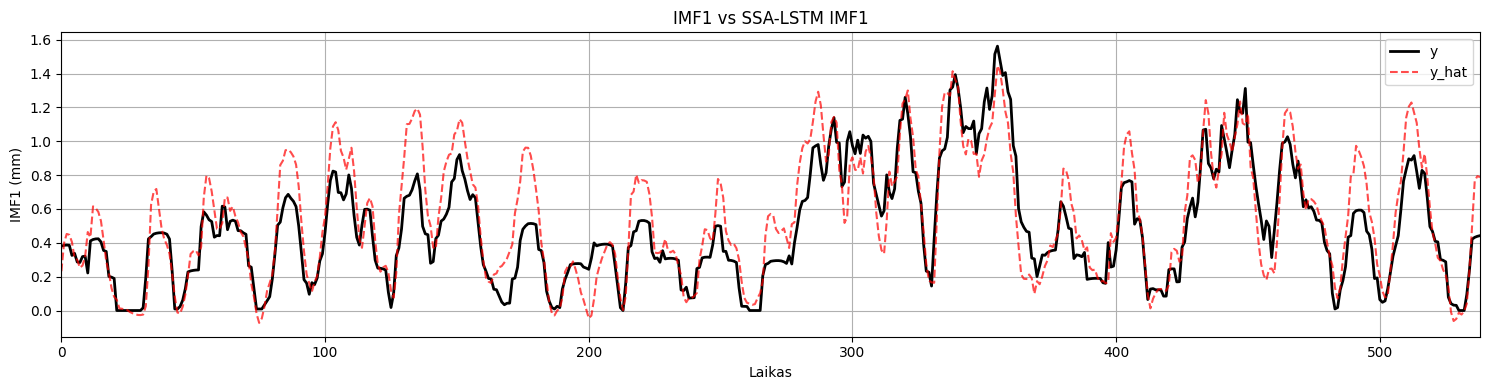

In [130]:
plt.figure(figsize=(15, 4))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF1 vs SSA-LSTM IMF1")
plt.xlabel("Laikas")
plt.ylabel("IMF1 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

R2: 0.9845


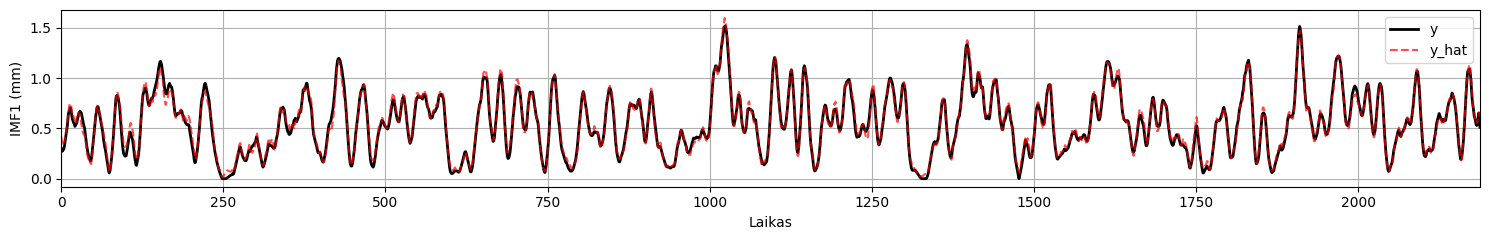

In [74]:
IMF1_fit = pipeline.predict(X_train_IMF1.values)
print(f"R2: {r2_score(y_train['IMF1'][14:], IMF1_fit):.4f}")

plt.figure(figsize=(15, 2.5))
plt.plot(y_train['IMF1'][14:].values, label="y", linewidth=2, color='black')
plt.plot(IMF1_fit, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(IMF1_fit) - 1)
plt.xlabel("Laikas")
plt.ylabel("IMF1 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF2

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 14}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 5}

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 7} R2:       0.3472

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 5}

In [133]:
pipeline = LSTMNet(
    base_module=LSTMRegressor,
    window_size=10,

    module__hidden_dim=128,
    module__num_layers=1,
    module__dropout=0.2,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=20, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=64,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=1.0),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [134]:
pipeline.fit(X_train_IMF2.values, y_train['IMF2'].values)
pred = pipeline.predict(X_test_IMF2.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0070        0.0020     +  0.3434
      2        0.0017        0.0011     +  0.1380
      3        0.0007        0.0006     +  0.1396
      4        0.0004        0.0004     +  0.1410
      5        0.0003        0.0002     +  0.1375
      6        0.0002        0.0002     +  0.1340
      7        0.0002        0.0001     +  0.1414
      8        0.0002        0.0001     +  0.1346
      9        0.0002        0.0001     +  0.1423
     10        0.0002        0.0001     +  0.1273
     11        0.0001        0.0001     +  0.1421
     12        0.0001        0.0001        0.1332
     13        0.0001        0.0002        0.1474
     14        0.0002        0.0002        0.1504
     15        0.0001        0.0001        0.1457
     16        0.0001        0.0001     +  0.1355
     17        0.0001        0.0001     +  0.1353
     18        0.0001        0.0001        0.1367


In [132]:
param_grid = {
    'window_size': [1, 3, 5],
    'module__hidden_dim': [128],
    'module__num_layers': [1, 2, 3],
    'lr': [0.001],          
    'module__dropout': [0.2, 0.3],
    'batch_size': [32, 64],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF2.values, y_train['IMF2'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF2.values)

Fitting 2 folds for each of 36 candidates, totalling 72 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0128        0.0119     +  0.2536
      2        0.0089        0.0096     +  0.1892
      3        0.0080        0.0087     +  0.1362
      4        0.0076        0.0083     +  0.0753
      5        0.0073        0.0080     +  0.0794
      6        0.0071        0.0078     +  0.0864
      7        0.0070        0.0077     +  0.0791
      8        0.0069        0.0075     +  0.0838
      9        0.0068        0.0074     +  0.0757
     10        0.0067        0.0073     +  0.0773
     11        0.0066        0.0072     +  0.0730
     12        0.0065        0.0072     +  0.0923
     13        0.0064        0.0071     +  0.1002
     14        0.0064        0.0070     +  0.0967
     15        0.0063        0.0069     +  0.0880
     16        0.0062        0.0069     +  0.0794
     17        0.0061        0.0068    

In [135]:
y_true = y_test['IMF2'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[10:]
y_pred = np.array(pred).reshape(-1)
# y_pred = np.expm1(y_pred)

# Sulygiuojame ilgius
# min_len = min(len(y_true), len(y_pred))
# y_true = y_true[:min_len]
# y_pred = y_pred[:min_len]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF2 = y_true[4:]
y_pred_IMF2 = y_pred[4:]

RMSE:     0.2193
MAE:      0.1669
R2:       0.5714
Spearman: 0.7421


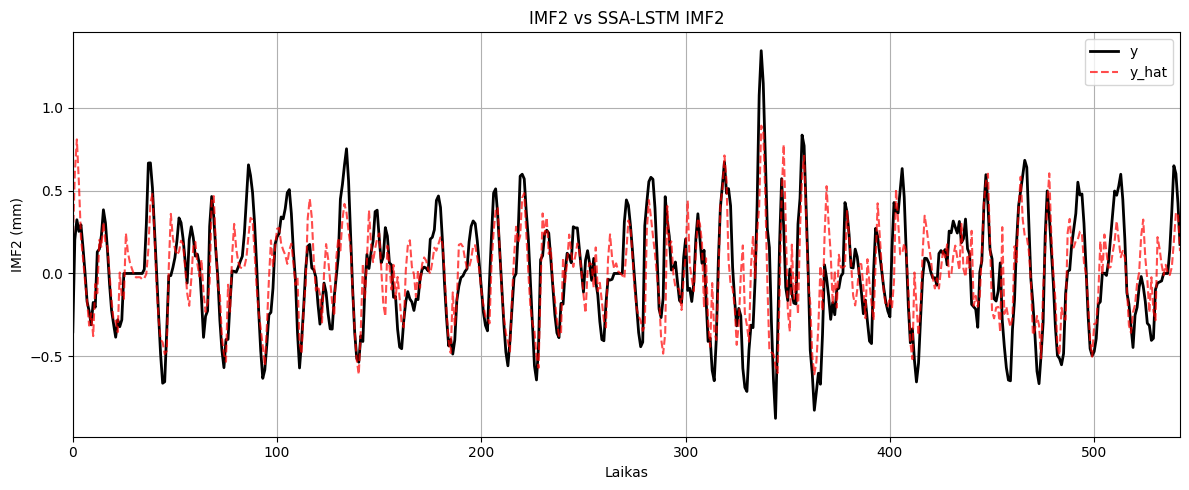

In [136]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF2 vs SSA-LSTM IMF2")
plt.xlabel("Laikas")
plt.ylabel("IMF2 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

R2: 0.9966


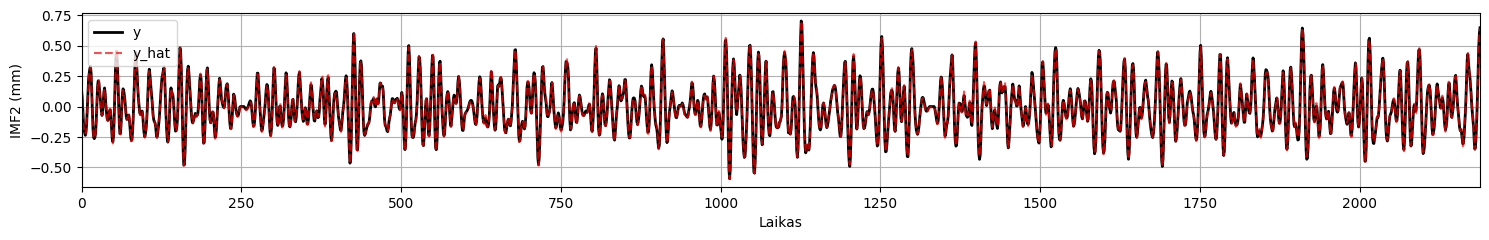

In [137]:
IMF2_fit = pipeline.predict(X_train_IMF2.values)[4:]
print(f"R2: {r2_score(y_train['IMF2'][14:], IMF2_fit):.4f}")

plt.figure(figsize=(15, 2.5))
plt.plot(y_train['IMF2'][14:].values, label="y", linewidth=2, color='black')
plt.plot(IMF2_fit, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(IMF2_fit) - 1)
plt.xlabel("Laikas")
plt.ylabel("IMF2 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF3

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 14}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 5}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.4, 'module__hidden_dim': 256, 'module__num_layers': 1, 'window_size': 3}

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 256, 'module__num_layers': 2, 'window_size': 3}

In [143]:
pipeline = LSTMNet(
    base_module=LSTMRegressor,
    window_size=5,

    module__hidden_dim=256,
    module__num_layers=2,
    module__dropout=0.3,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=10, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=64,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=1.0),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [144]:
pipeline.fit(X_train_IMF3.values, y_train['IMF3_diff'].values)
pred = pipeline.predict(X_test_IMF3.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0037        0.0009     +  0.3978
      2        0.0006        0.0003     +  0.1778
      3        0.0004        0.0003     +  0.1794
      4        0.0003        0.0002     +  0.1763
      5        0.0002        0.0002     +  0.1568
      6        0.0002        0.0002     +  0.1709
      7        0.0002        0.0002        0.1607
      8        0.0002        0.0002        0.1652
      9        0.0002        0.0002        0.1999
     10        0.0002        0.0002        0.1828
     11        0.0002        0.0002        0.1853
     12        0.0002        0.0002        0.1732
     13        0.0002        0.0002        0.2192
     14        0.0002        0.0002        0.1827
     15        0.0002        0.0002        0.1682
Stopping since valid_loss has not improved in the last 10 epochs.


In [142]:
param_grid = {
    'window_size': [3, 5],
    'module__hidden_dim': [128, 256],
    'module__num_layers': [1, 2],
    'lr': [0.001],          
    'module__dropout': [0.3, 0.4],
    'batch_size': [32, 64],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF3.values, y_train['IMF3_diff'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF3.values)

Fitting 2 folds for each of 32 candidates, totalling 64 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0040        0.0030     +  0.3694
      2        0.0017        0.0013     +  0.0900
      3        0.0006        0.0004     +  0.0895
      4        0.0003        0.0004     +  0.0843
      5        0.0002        0.0002     +  0.0882
      6        0.0002        0.0002     +  0.0895
      7        0.0001        0.0002     +  0.0745
      8        0.0001        0.0002        0.0826
      9        0.0002        0.0005        0.0933
     10        0.0002        0.0002        0.0826
     11        0.0003        0.0009        0.0808
     12        0.0002        0.0002        0.0825
     13        0.0001        0.0002        0.0780
     14        0.0001        0.0002     +  0.0836
     15        0.0001        0.0002     +  0.0837
     16        0.0001        0.0002        0.0858
     17        0.0001        0.0002    

In [145]:
y_true = y_test['IMF3_diff'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[5:]
y_pred = np.array(pred).reshape(-1)
# y_pred = np.expm1(y_pred)

# Sulygiuojame ilgius
# min_len = min(len(y_true), len(y_pred))
# y_true = y_true[:min_len]
# y_pred = y_pred[:min_len]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF3 = y_true[9:]
y_pred_IMF3 = y_pred[9:]

RMSE:     0.2121
MAE:      0.1652
R2:       0.1050
Spearman: 0.2785


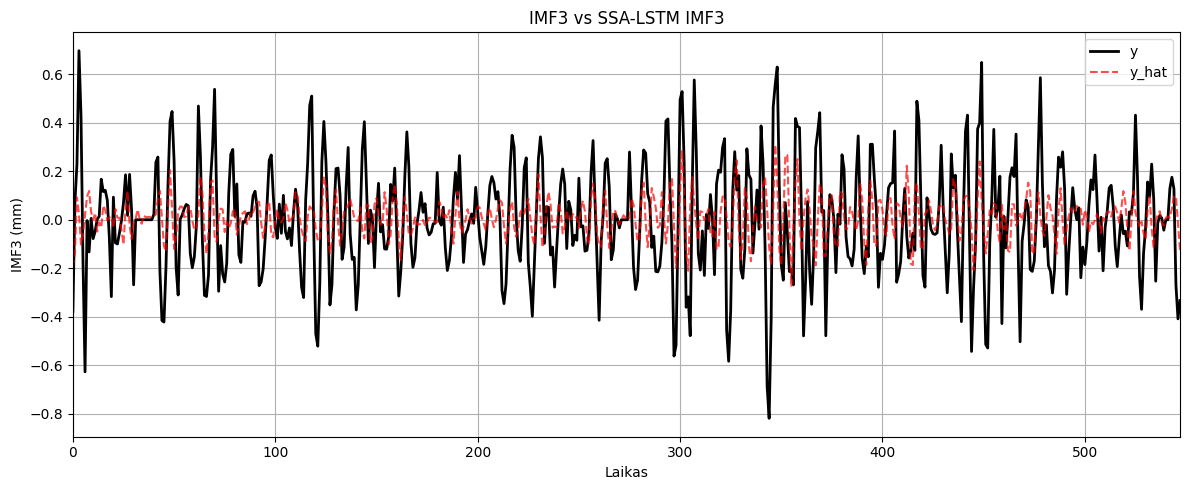

In [146]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF3 vs SSA-LSTM IMF3")
plt.xlabel("Laikas")
plt.ylabel("IMF3 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF4

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 14}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 3}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 256, 'module__num_layers': 1, 'window_size': 3}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 256, 'module__num_layers': 2, 'window_size': 3}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 5}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 5}

32 0.1 128 2 5

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 3}

In [153]:
pipeline = LSTMNet(
    base_module=LSTMFCRegressor,
    window_size=3,

    module__hidden_dim=128,
    module__num_layers=2,
    module__dropout=0.1,
    optimizer__weight_decay = 0,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=12, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.01,
    batch_size=32,
    optimizer=torch.optim.Adam,
    criterion=nn.HuberLoss(delta=1),
    # criterion=nn.L1Loss(),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [154]:
pipeline.fit(X_train_IMF4.values, y_train['IMF4_diff'].values)
pred = pipeline.predict(X_test_IMF4.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0123        0.0066     +  0.4917
      2        0.0118        0.0089        0.2921
      3        0.0081        0.0091        0.2989
      4        0.0077        0.0081        0.2859
      5        0.0051        0.0081        0.2804
      6        0.0042        0.0043     +  0.2900
      7        0.0031        0.0033     +  0.3044
      8        0.0032        0.0043        0.2946
      9        0.0020        0.0032     +  0.2919
     10        0.0038        0.0040        0.2932
     11        0.0027        0.0034        0.2953
     12        0.0024        0.0039        0.3076
     13        0.0020        0.0035        0.3016
     14        0.0018        0.0042        0.2912
     15        0.0015        0.0039        0.2942
     16        0.0015        0.0039        0.2979
     17        0.0014        0.0036        0.3043
     18        0.0010        0.0032     +  0.2970


In [148]:
param_grid = {
    'window_size': [3, 5],
    'module__hidden_dim': [64, 128],
    'module__num_layers': [1, 2],
    'lr': [0.001],          
    'module__dropout': [0.1, 0.2],
    'batch_size': [16, 32],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF4.values, y_train['IMF4_diff'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF4.values)

Fitting 2 folds for each of 32 candidates, totalling 64 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0143        0.0127     +  0.3618
      2        0.0108        0.0094     +  0.1822
      3        0.0076        0.0080     +  0.1814
      4        0.0108        0.0114        0.1829
      5        0.0071        0.0069     +  0.1768
      6        0.0048        0.0054     +  0.1586
      7        0.0035        0.0044     +  0.1655
      8        0.0025        0.0038     +  0.1590
      9        0.0019        0.0036     +  0.1712
     10        0.0016        0.0034     +  0.1547
     11        0.0017        0.0032     +  0.1575
     12        0.0033        0.0051        0.1526
     13        0.0038        0.0069        0.1649
     14        0.0029        0.0037        0.1672
     15        0.0014        0.0030     +  0.1540
     16        0.0010        0.0030        0.1699
     17        0.0012        0.0034    

In [156]:
y_true = y_test['IMF4_diff'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[3:]
y_pred = np.array(pred).reshape(-1)[:]
# y_pred = np.expm1(y_pred)


rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF4 = y_true[11:]
y_pred_IMF4 = y_pred[11:]

RMSE:     0.3301
MAE:      0.2415
R2:       -0.2936
Spearman: 0.0585


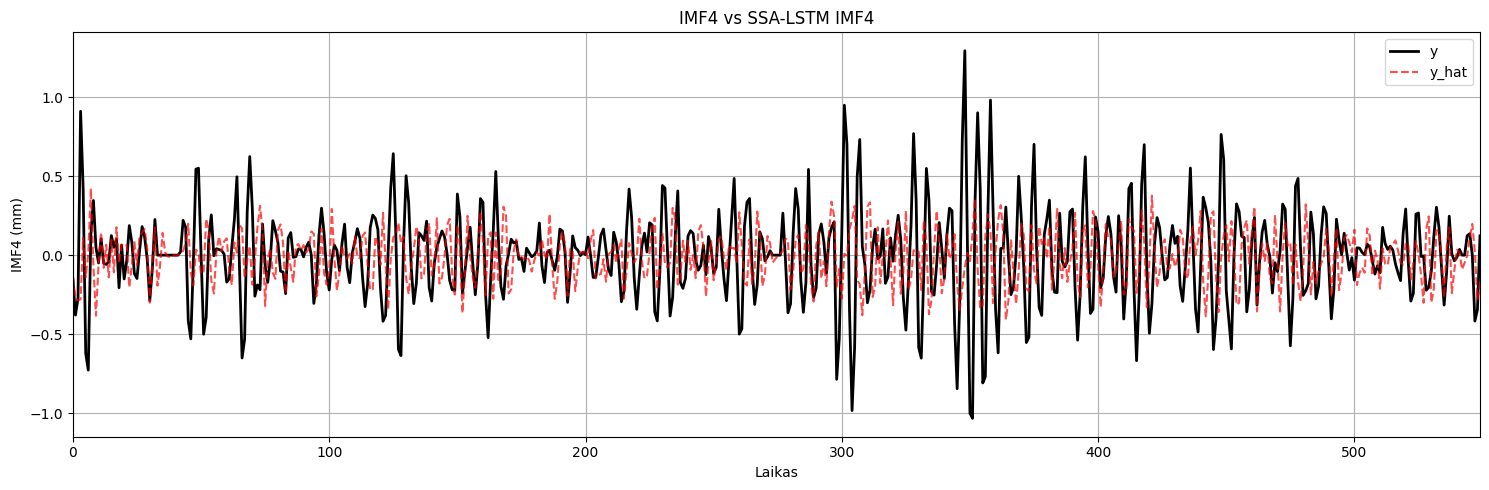

In [157]:
plt.figure(figsize=(15, 5))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF4 vs SSA-LSTM IMF4")
plt.xlabel("Laikas")
plt.ylabel("IMF4 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF5

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 14}

{'batch_size': 16, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 64, 'module__num_layers': 2, 'window_size': 5}

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 2}

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 5}

In [160]:
pipeline = LSTMNet(
    base_module=LSTMRegressor,
    window_size=5,

    module__hidden_dim=128,
    module__num_layers=2,
    module__dropout=0.2,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=15, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=64,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=1),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [161]:
pipeline.fit(X_train_IMF5.values, y_train['IMF5'].values)
pred = pipeline.predict(X_test_IMF5.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0092        0.0044     +  0.3495
      2        0.0033        0.0013     +  0.1435
      3        0.0012        0.0007     +  0.1392
      4        0.0008        0.0006     +  0.1444
      5        0.0008        0.0006     +  0.1427
      6        0.0007        0.0005     +  0.1357
      7        0.0007        0.0005     +  0.1487
      8        0.0006        0.0005     +  0.1633
      9        0.0006        0.0005     +  0.1419
     10        0.0005        0.0005     +  0.1515
     11        0.0005        0.0004     +  0.1493
     12        0.0005        0.0004     +  0.1554
     13        0.0005        0.0004        0.1472
     14        0.0004        0.0004        0.1407
     15        0.0005        0.0005        0.1427
     16        0.0004        0.0004     +  0.1577
     17        0.0004        0.0004        0.1496
     18        0.0004        0.0004        0.1569


In [159]:
param_grid = {
    'window_size': [2, 3, 5],
    'module__hidden_dim': [64, 128],
    'module__num_layers': [1, 2, 3],
    'lr': [0.001, 0.01],          
    'module__dropout': [0.1, 0.2, 0.3],
    'batch_size': [32, 64],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF5.values, y_train['IMF5'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF5.values)

Fitting 2 folds for each of 216 candidates, totalling 432 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0104        0.0083     +  0.2893
      2        0.0050        0.0051     +  0.1573
      3        0.0029        0.0035     +  0.1541
      4        0.0021        0.0026     +  0.0927
      5        0.0015        0.0019     +  0.0925
      6        0.0011        0.0014     +  0.0975
      7        0.0008        0.0011     +  0.0937
      8        0.0006        0.0009     +  0.0976
      9        0.0005        0.0008     +  0.0933
     10        0.0004        0.0007     +  0.0960
     11        0.0004        0.0007     +  0.1017
     12        0.0004        0.0007     +  0.0912
     13        0.0004        0.0007     +  0.0876
     14        0.0003        0.0007     +  0.0804
     15        0.0003        0.0007     +  0.0854
     16        0.0003        0.0007     +  0.0939
     17        0.0003        0.0007  

In [166]:
y_true = y_test['IMF5'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[5:]
y_pred = np.array(pred).reshape(-1)[:]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF5 = y_true[9:]
y_pred_IMF5 = y_pred[9:]

RMSE:     0.2584
MAE:      0.1876
R2:       0.2927
Spearman: 0.5620


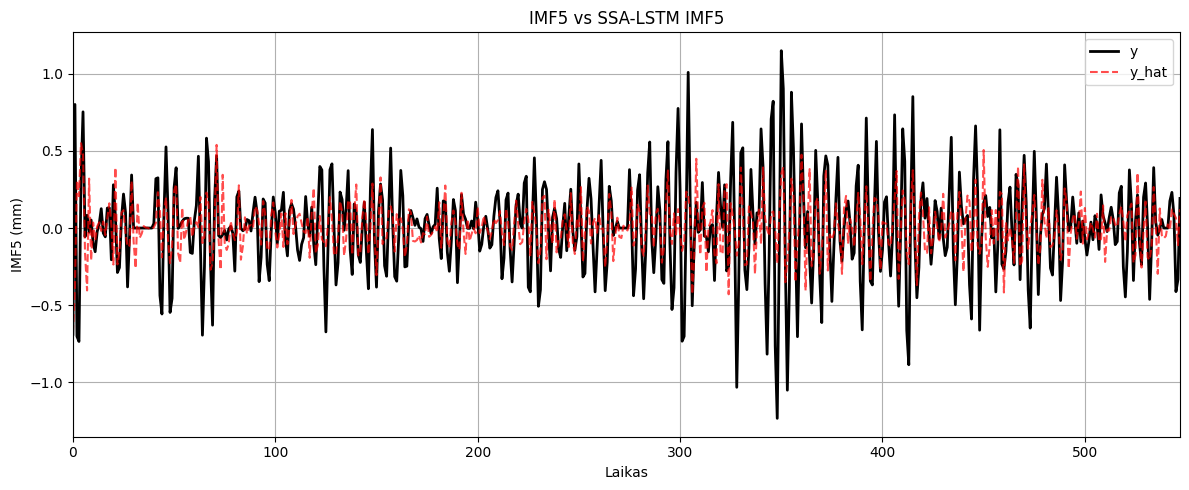

In [167]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF5 vs SSA-LSTM IMF5")
plt.xlabel("Laikas")
plt.ylabel("IMF5 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF6

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 14}

{'batch_size': 16, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 7}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 256, 'module__num_layers': 2, 'window_size': 7}

{'batch_size': 16, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 5}

In [171]:
pipeline = LSTMNet(
    base_module=LSTMFCRegressor,
    window_size=5,

    module__hidden_dim=128,
    module__num_layers=2,
    module__dropout=0.2,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=10, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=16,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=0.5),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [172]:
pipeline.fit(X_train_IMF6.values, y_train['IMF6_diff'].values)
pred = pipeline.predict(X_test_IMF6.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0112        0.0068     +  0.7439
      2        0.0054        0.0029     +  0.5420
      3        0.0031        0.0021     +  0.6152
      4        0.0033        0.0035        0.5253
      5        0.0033        0.0025        0.4999
      6        0.0021        0.0013     +  0.5873
      7        0.0021        0.0021        0.5484
      8        0.0027        0.0015        0.5733
      9        0.0019        0.0013     +  0.6722
     10        0.0016        0.0012     +  0.6745
     11        0.0017        0.0014        0.7635
     12        0.0014        0.0011     +  0.5771
     13        0.0011        0.0009     +  0.5942
     14        0.0014        0.0011        0.5894
     15        0.0011        0.0012        0.5500
     16        0.0012        0.0011        0.5372
     17        0.0008        0.0008     +  0.5699
     18        0.0011        0.0009        0.5255


In [170]:
param_grid = {
    'window_size': [5, 7],
    'module__hidden_dim': [128, 256],
    'module__num_layers': [1, 2],
    'lr': [0.001],          
    'module__dropout': [0.1, 0.2],
    'batch_size': [16, 32],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF6.values, y_train['IMF6_diff'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF6.values)

Fitting 2 folds for each of 32 candidates, totalling 64 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0113        0.0104     +  0.3978
      2        0.0093        0.0132        0.1641
      3        0.0070        0.0065     +  0.1463
      4        0.0040        0.0042     +  0.1588
      5        0.0028        0.0040     +  0.1538
      6        0.0024        0.0035     +  0.1493
      7        0.0020        0.0033     +  0.1465
      8        0.0023        0.0035        0.1622
      9        0.0022        0.0031     +  0.1511
     10        0.0016        0.0028     +  0.1549
     11        0.0013        0.0029        0.1527
     12        0.0012        0.0027     +  0.1444
     13        0.0011        0.0027     +  0.1543
     14        0.0011        0.0029        0.1543
     15        0.0014        0.0034        0.1510
     16        0.0011        0.0029        0.1669
     17        0.0009        0.0027    

In [175]:
y_true = y_test['IMF6_diff'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[5:]
y_pred = np.array(pred).reshape(-1)[:]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF6 = y_true[9:]
y_pred_IMF6 = y_pred[9:]

RMSE:     0.3914
MAE:      0.2945
R2:       0.3439
Spearman: 0.5443


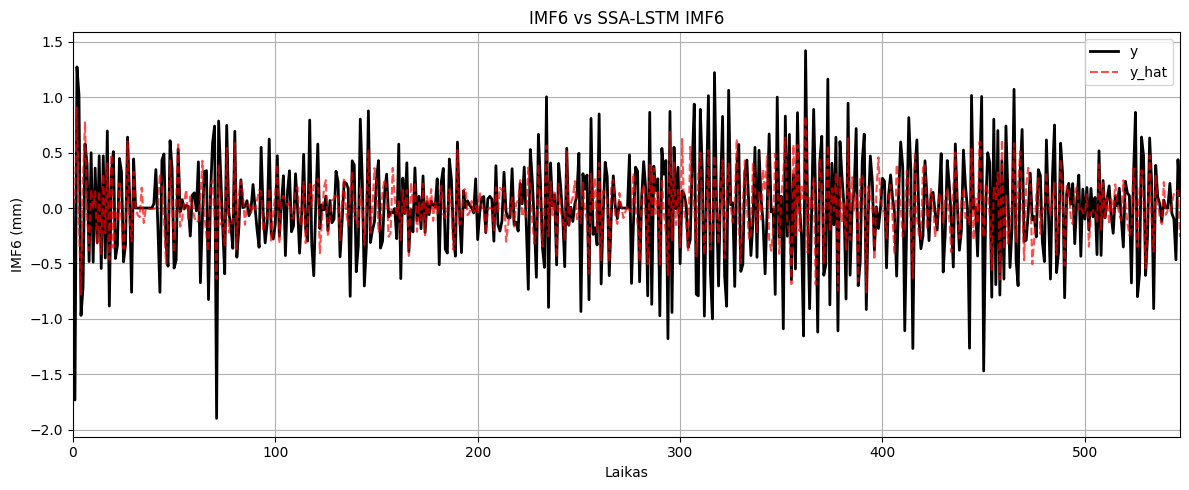

In [176]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF6 vs SSA-LSTM IMF6")
plt.xlabel("Laikas")
plt.ylabel("IMF6 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF7

{'batch_size': 32, 'lr': 0.01, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 14}

 {'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 5}

 {'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 256, 'module__num_layers': 1, 'window_size': 5}

 {'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 256, 'module__num_layers': 1, 'window_size': 5}

 {'batch_size': 32, 'lr': 0.01, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 5} R2:       0.2381

 {'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 4}

 {'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 256, 'module__num_layers': 1, 'window_size': 4}

 {'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 256, 'module__num_layers': 2, 'window_size': 5}

In [188]:
pipeline = LSTMNet(
    base_module=LSTMFCRegressor,
    window_size=3,

    module__hidden_dim=128,
    module__num_layers=2,
    module__dropout=0.3,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=15, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.01,
    batch_size=32,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=3),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [189]:
pipeline.fit(X_train_IMF7.values, y_train['IMF7'].values)
pred = pipeline.predict(X_test_IMF7.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0088        0.0074     +  0.4640
      2        0.0065        0.0039     +  0.2872
      3        0.0047        0.0026     +  0.2643
      4        0.0043        0.0032        0.2819
      5        0.0039        0.0037        0.2718
      6        0.0039        0.0025     +  0.2747
      7        0.0032        0.0028        0.3042
      8        0.0025        0.0029        0.2803
      9        0.0020        0.0028        0.2815
     10        0.0021        0.0037        0.3187
     11        0.0023        0.0024     +  0.3072
     12        0.0020        0.0038        0.3637
     13        0.0016        0.0032        0.2804
     14        0.0019        0.0024        0.2800
     15        0.0014        0.0025        0.2893
     16        0.0009        0.0024        0.2773
     17        0.0008        0.0022     +  0.2809
     18        0.0008        0.0024        0.2941


In [178]:
param_grid = {
    'window_size': [4, 5],
    'module__hidden_dim': [128, 256],
    'module__num_layers': [1, 2],
    'lr': [0.001, 0.01],          
    'module__dropout': [0.3],
    'batch_size': [32],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF7.values, y_train['IMF7'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF7.values)

Fitting 2 folds for each of 16 candidates, totalling 32 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0063        0.0079     +  0.2659
      2        0.0058        0.0059     +  0.0798
      3        0.0040        0.0032     +  0.0810
      4        0.0032        0.0028     +  0.0794
      5        0.0022        0.0022     +  0.0882
      6        0.0017        0.0021     +  0.0799
      7        0.0015        0.0019     +  0.0786
      8        0.0015        0.0021        0.0769
      9        0.0019        0.0029        0.0764
     10        0.0016        0.0021        0.0836
     11        0.0022        0.0033        0.0829
     12        0.0017        0.0023        0.0796
     13        0.0014        0.0021        0.0826
     14        0.0011        0.0018     +  0.0803
     15        0.0008        0.0016     +  0.0831
     16        0.0007        0.0016     +  0.0821
     17        0.0006        0.0015    

In [190]:
y_true = y_test['IMF7'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[3:]
y_pred = np.array(pred).reshape(-1)[:]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF7 = y_true[11:]
y_pred_IMF7 = y_pred[11:]

RMSE:     0.0840
MAE:      0.0681
R2:       -18.1413
Spearman: -0.1877


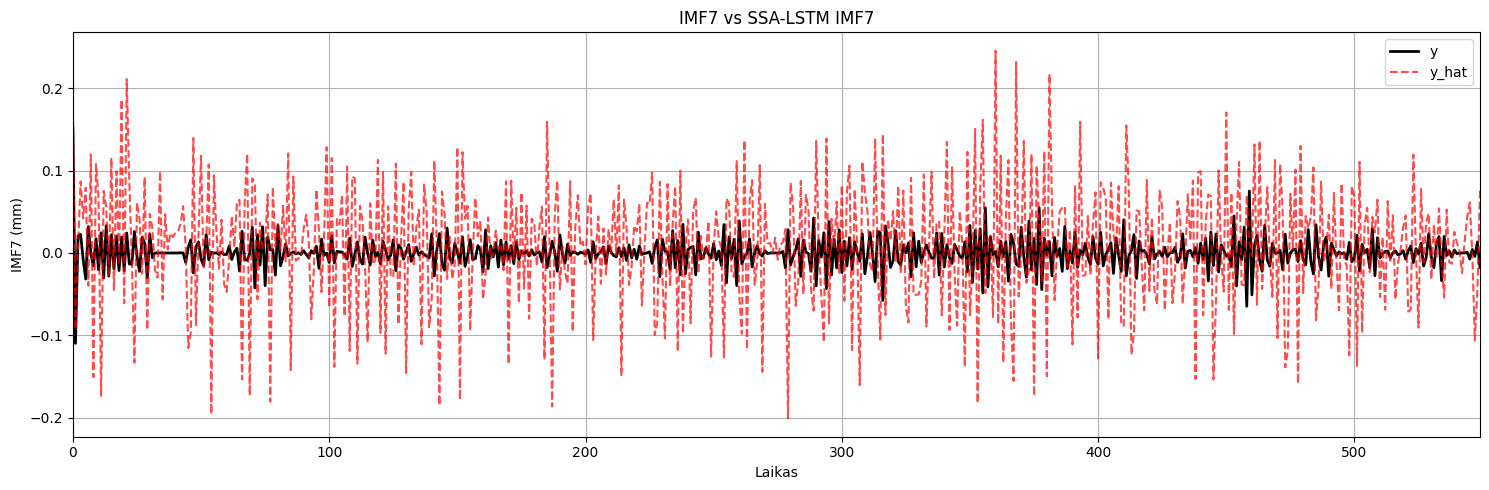

In [191]:
plt.figure(figsize=(15, 5))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF7 vs SSA-LSTM IMF7")
plt.xlabel("Laikas")
plt.ylabel("IMF7 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF8

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 14}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 7}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 256, 'module__num_layers': 2, 'window_size': 7}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 5} R2:       -0.3563

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 5} R2:       -0.1534

In [192]:
pipeline = LSTMNet(
    base_module=LSTMFCRegressor,
    window_size=3,

    module__hidden_dim=128,
    module__num_layers=2,
    module__dropout=0.3,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=15, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=64,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=0.5),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [193]:
pipeline.fit(X_train_IMF8.values, y_train['IMF8'].values)
pred = pipeline.predict(X_test_IMF8.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0429        0.0387     +  0.3279
      2        0.0337        0.0284     +  0.1748
      3        0.0275        0.0257     +  0.1696
      4        0.0245        0.0240     +  0.1693
      5        0.0227        0.0229     +  0.1639
      6        0.0213        0.0221     +  0.1744
      7        0.0197        0.0217     +  0.1620
      8        0.0189        0.0215     +  0.1648
      9        0.0175        0.0206     +  0.1637
     10        0.0168        0.0196     +  0.1487
     11        0.0163        0.0192     +  0.1618
     12        0.0148        0.0190     +  0.1616
     13        0.0146        0.0188     +  0.1506
     14        0.0132        0.0177     +  0.1546
     15        0.0133        0.0180        0.1609
     16        0.0124        0.0173     +  0.1551
     17        0.0118        0.0176        0.1585
     18        0.0119        0.0179        0.1511


In [178]:
param_grid = {
    'window_size': [5],
    'module__hidden_dim': [64, 128, 256],
    'module__num_layers': [1, 2],
    'lr': [0.001],
    'module__dropout': [0.3],
    'batch_size': [32, 64],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF8.values, y_train['IMF8'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF8.values)

Fitting 2 folds for each of 12 candidates, totalling 24 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0517        0.0452     +  0.2545
      2        0.0478        0.0435     +  0.0888
      3        0.0453        0.0413     +  0.0918
      4        0.0421        0.0385     +  0.0954
      5        0.0380        0.0363     +  0.1027
      6        0.0339        0.0359     +  0.0951
      7        0.0298        0.0328     +  0.1078
      8        0.0242        0.0319     +  0.1037
      9        0.0217        0.0327        0.0957
     10        0.0194        0.0319     +  0.1038
     11        0.0159        0.0313     +  0.1105
     12        0.0130        0.0315        0.1178
     13        0.0111        0.0333        0.1038
     14        0.0096        0.0319        0.1116
     15        0.0074        0.0334        0.1053
     16        0.0063        0.0326        0.1094
     17        0.0047        0.0322    

In [194]:
y_true = y_test['IMF8'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[3:]
y_pred = np.array(pred).reshape(-1)[:]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF8 = y_true[11:]
y_pred_IMF8 = y_pred[11:]

RMSE:     0.4392
MAE:      0.3221
R2:       -1.7491
Spearman: 0.0063


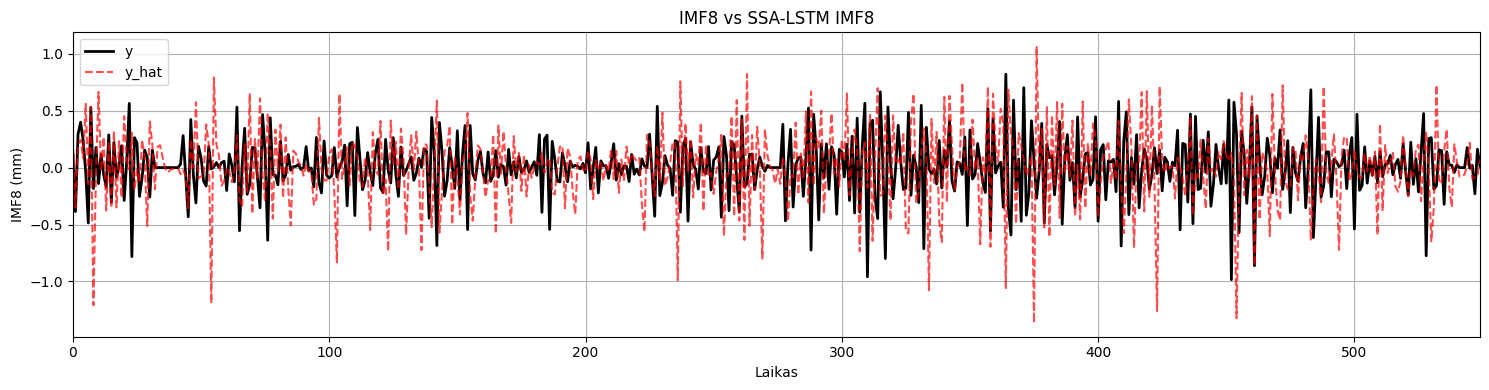

In [195]:
plt.figure(figsize=(15, 4))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF8 vs SSA-LSTM IMF8")
plt.xlabel("Laikas")
plt.ylabel("IMF8 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## SSA-LSTM rezultatai

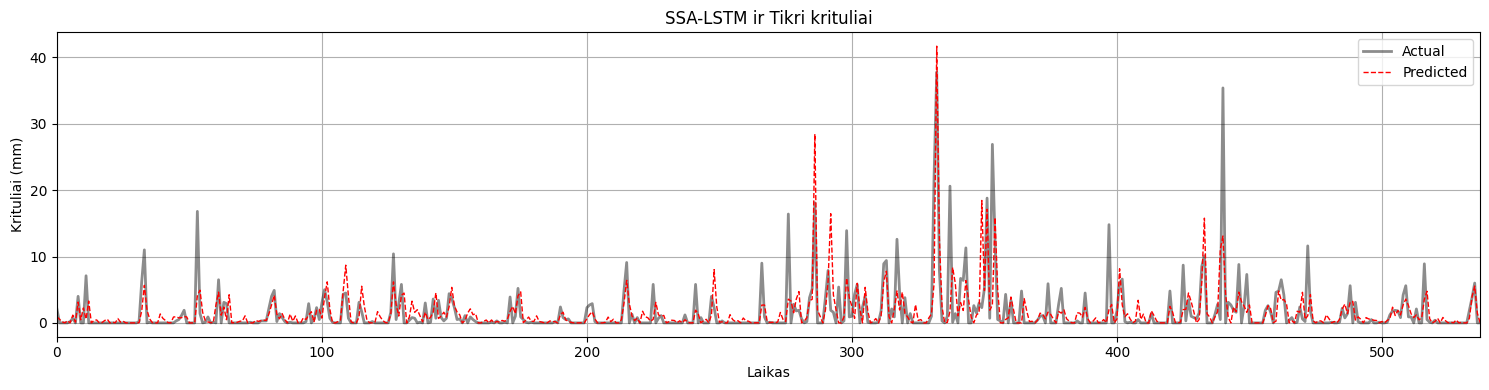

In [196]:
y_pred_IMF3_lvl = X_test_raw['IMF3'].values[14:] + y_pred_IMF3

y_pred_IMF4_lvl = X_test_raw['IMF4'].values[14:] + y_pred_IMF4

y_pred_IMF6_lvl = X_test_raw['IMF6'].values[14:] + y_pred_IMF6

y_true_final = np.expm1(y_original_imf['IMF1'].values.astype(float) + 
                        y_original_imf['IMF2'].values.astype(float) + 
                        y_original_imf['IMF3'].values.astype(float) + 
                        y_original_imf['IMF4'].values.astype(float) + 
                        y_original_imf['IMF5'].values.astype(float) + 
                        y_original_imf['IMF6'].values.astype(float) + 
                        y_original_imf['IMF7'].values.astype(float) + 
                        y_original_imf['IMF8'].values.astype(float))[14:]
y_pred_final = np.expm1(y_pred_IMF1[:] + y_pred_IMF2[:] + y_pred_IMF3_lvl[:] + y_pred_IMF4_lvl[:] + y_pred_IMF5 + y_pred_IMF6_lvl[:] + y_pred_IMF7 + y_pred_IMF8)[:].clip(min=0)
y_actual_precipitation = data['missforest_precipitation'][(int(len(data)*0.8) + 14):-1].values
# y_actual_precipitation = data['missforest_precipitation'][(2017 + 14):-1].values


plt.figure(figsize=(15, 4))
plt.plot(y_actual_precipitation, label="Actual", linewidth=2, alpha=0.45, color = 'black')
# plt.plot(y_true_final, label="True", linewidth=1.2, alpha = 0.8)
plt.plot(y_pred_final, label="Predicted", linewidth=1, alpha=1, color='red', linestyle='--')
plt.xlim(0, len(y_actual_precipitation) - 1)
plt.title("SSA-LSTM ir Tikri krituliai")
plt.xlabel("Laikas")
plt.ylabel("Krituliai (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [197]:
rmse = np.sqrt(mean_squared_error(y_true_final, y_pred_final))
mae  = mean_absolute_error(y_true_final, y_pred_final)
r2   = r2_score(y_true_final, y_pred_final)
spearman_corr, _ = spearmanr(y_true_final, y_pred_final)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

RMSE:     2.9356
MAE:      1.3793
R2:       0.4164
Spearman: 0.5095


In [198]:
rmse = np.sqrt(mean_squared_error(y_actual_precipitation, y_pred_final[:-1]))
mae  = mean_absolute_error(y_actual_precipitation, y_pred_final[:-1])
r2   = r2_score(y_actual_precipitation, y_pred_final[:-1])
spearman_corr, _ = spearmanr(y_actual_precipitation, y_pred_final[:-1])

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

RMSE:     2.9384
MAE:      1.3819
R2:       0.4162
Spearman: 0.6015


In [199]:
data[data['missforest_precipitation']==2.1][['missforest_precipitation', 'observationTime']]

,missforest_precipitation,observationTime
98,2.1,2018-10-07
113,2.1,2018-10-22
174,2.1,2018-12-22
367,2.1,2019-07-03
463,2.1,2019-10-07
834,2.1,2020-10-12
1215,2.1,2021-10-28
1272,2.1,2021-12-24
1492,2.1,2022-08-01
1711,2.1,2023-03-08


In [ ]:
results_df = pd.DataFrame({
    'observationTime': observation_times.iloc[(split_idx+14):-1].reset_index(drop=True),
    # 'observationTime': observation_times.iloc[(2017+14):-1].reset_index(drop=True),
    'actual': y_actual_precipitation,
    'SSA-LSTM': y_pred_final[:-1]
})
results_df

# results_df.to_csv('SSA-LSTM_pred_less_features.csv')